In [1]:
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
from Wavmat import Wavmat 
from scipy import signal
from MakeONFilter import MakeONFilterExt
import dcor
import pywt

In [2]:
# import predictors and response data
sst = np.loadtxt('SST.txt')
amo = np.loadtxt('AMO.txt')
nno = np.loadtxt('NINO3.txt')
pdo = np.loadtxt('pdoall.txt')
nh  = np.loadtxt('nhall.txt')
tcr = np.loadtxt('TC_reconstructed.txt')

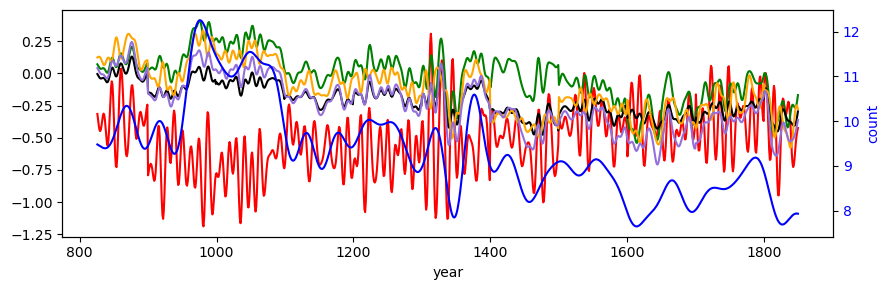

In [3]:
fig, ax1 = plt.subplots(figsize=(9,3))

ax1.set_xlabel('year')
ax1.plot(nno[326:1350, 0], nno[326:1350, 1], color='r')
ax1.plot(amo[326:1350, 0], amo[326:1350, 1], color='g')
ax1.plot(sst[326:1350, 0], sst[326:1350, 1], color='k')
ax1.plot(pdo[326:1350, 0], pdo[326:1350, 1], color='orange')
ax1.plot(nh[326:1350, 0], nh[326:1350, 1], color='mediumpurple')
ax1.plot()

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('count', color='b')
ax2.plot(tcr[326:1350,0], tcr[326:1350,1], color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

### GLM Model

In [30]:
import statsmodels.api as sm

# shapes of data
datalist = [sst, amo, nno, pdo, nh, tcr]
for i in datalist:
    print(i.shape)
    print(i[-1,0])

(1507, 4)
2006.0
(1507, 4)
2006.0
(1507, 4)
2006.0
(1507, 4)
2006.0
(1507, 4)
2006.0
(1351, 2)
1850.0


All data contains 1507 records except the tc reconstruction. We will first use the first 1,351 records from all the predictors to build the model and assess the relationships. From there, we can also try splitting the 1,351 records into train/test splits, or use the 1,351 records as training and the new tc records to test.

In [37]:
# adjust records
sst_g = sst[0:1351, 1]
amo_g = amo[0:1351, 1]
nno_g = nno[0:1351, 1]
pdo_g = pdo[0:1351, 1]
nh_g  =  nh[0:1351, 1]
tcr_g = tcr[0:1351, 1]

# standardize response
mintc = np.min(tcr_g)
tcr_g = tcr_g - mintc

In [51]:
# design matrix
X1 = np.array([np.ones(sst_g.shape), sst_g, amo_g, nno_g, pdo_g, nh_g])
X = np.transpose(X1)
# X.shape (1351, 6)

# fit GLM with Poisson family for count outcome
model = sm.GLM(tcr_g, X, family=sm.families.Poisson()) 
results = model.fit()

# print summary of the model
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1351
Model:                            GLM   Df Residuals:                     1345
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1636.0
Date:                Wed, 13 Aug 2025   Deviance:                       96.661
Time:                        20:19:03   Pearson chi2:                     86.3
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3851
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3082      0.054      5.735      0.0

x1 = SST, x2 = AMO, x3 = ENSO, x4 = PDO, x5 = NH

In [52]:
# try it without standardizing counts?
tcr_g2 = tcr[0:1351, 1]

# fit GLM with Poisson family for count outcome
model2 = sm.GLM(tcr_g2, X, family=sm.families.Poisson()) 
results2 = model2.fit()

# print summary of the model
print(results2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 1351
Model:                            GLM   Df Residuals:                     1345
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2772.3
Date:                Wed, 13 Aug 2025   Deviance:                       14.600
Time:                        20:25:54   Pearson chi2:                     14.6
No. Iterations:                     4   Pseudo R-squ. (CS):            0.08357
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2122      0.023     98.217      0.0

### Define Functions

In [3]:
dyadic = [8, 16, 32, 64, 128, 256, 512, 1024]

def wdecomp(series, n, l, wavelet, taps, dyadic):
    # get wavelet filter
    hfilt = MakeONFilterExt(wavelet, taps)    

    # wavelet matrix
    W = Wavmat(n, hfilt, taps) 

    # WT of data by 'hfilt' @ 'l' levels of detail
    W = Wavmat(n, hfilt, l) 
    
    wd = W * series

    s_decomps = {}
    
    # extract coefficients at each level of decomposition
    for i in range(len(dyadic)-1):
        s_decomps[f'S_l{i+1}'] = np.squeeze(np.array(wd[dyadic[i]:dyadic[i+1]]))
    
    slist = list(s_decomps.keys())
    
    return slist, s_decomps

In [4]:
# get correlation coefficients between variables:

def getcorrs(alist, a_decomps, blist, b_decomps):  
    corrs = []

    for i in range(len(alist)):
        corrs.append(np.corrcoef(a_decomps[alist[i]], b_decomps[blist[i]])[0,1])
        
    # could also add information about statistical significance of these correlation coefficients
    
    return corrs
  

In [5]:
# get distance correlation coefficients between variables:

def getdcorrs(alist, a_decomps, blist, b_decomps):
    dcorrs = []
    for i in range(len(alist)):
        dcorrs.append(dcor.distance_correlation(a_decomps[alist[i]], b_decomps[blist[i]],method="avl"))
    
    return dcorrs

In [7]:
# confidence intervals
from scipy.stats import norm

def CI(n,r,a):
    w = 0.5*np.log((1+r)/(1-r))
    z = norm.ppf(1-(a/2))
    wL = w-(z/np.sqrt(n-3))
    wU = w+(z/np.sqrt(n-3))
    rCI = np.zeros(2)
    rCI[0] = (np.exp(2*wL)-1)/(np.exp(2*wL)+1)
    rCI[1] = (np.exp(2*wU)-1)/(np.exp(2*wU)+1)
    return rCI

def PCI(n,r,a,c):
    w = 0.5*np.log((1+r)/(1-r))
    z = norm.ppf(1-(a/2))
    wL = w-(z/np.sqrt(n-3-c))
    wU = w+(z/np.sqrt(n-3-c))
    rCI = np.zeros(2)
    rCI[0] = (np.exp(2*wL)-1)/(np.exp(2*wL)+1)
    rCI[1] = (np.exp(2*wU)-1)/(np.exp(2*wU)+1)
    return rCI

### Run Functions on All Data

In [6]:
# trim data for dyadic interval
sstw = sst[326:1350, 1]
amow = amo[326:1350, 1]
nnow = nno[326:1350, 1]
pdow = pdo[326:1350, 1]
nh_w =  nh[326:1350, 1]
tcrw = tcr[326:1350, 1]

# arrays should be 1024 x 1 
sstw = np.transpose(np.matrix(sstw))
amow = np.transpose(np.matrix(amow))
nnow = np.transpose(np.matrix(nnow))
pdow = np.transpose(np.matrix(pdow))
nh_w = np.transpose(np.matrix(nh_w))
tcrw = np.transpose(np.matrix(tcrw))

In [9]:
# define preliminary variables
dyadic = [8, 16, 32, 64, 128, 256, 512, 1024]
wavelet = 'Daubechies'
taps = 8
l = 7
n = 1024

# get all wavelet decomps
keys, sst_d = wdecomp(sstw, n, l, wavelet, taps, dyadic)
keys, amo_d = wdecomp(amow, n, l, wavelet, taps, dyadic)
keys, nno_d = wdecomp(nnow, n, l, wavelet, taps, dyadic)
keys, pdo_d = wdecomp(pdow, n, l, wavelet, taps, dyadic)
keys, nh_d  = wdecomp(nh_w, n, l, wavelet, taps, dyadic)
keys, tcr_d = wdecomp(tcrw, n, l, wavelet, taps, dyadic)

In [10]:
from itertools import combinations

var_list = [sst_d,amo_d,nno_d,pdo_d,nh_d, tcr_d]
namelist = ['sst', 'amo', 'nno', 'pdo', 'nh', 'tcr']

var_pairs = list(combinations(var_list, 2))
namepairs = list(combinations(namelist, 2))

In [11]:
allcorrs = []

for j in range(len(var_pairs)):
    alist = blist = keys
    a_decomps = var_pairs[j][0]
    b_decomps = var_pairs[j][1]
    corrs = getcorrs(alist, a_decomps, blist, b_decomps)
    allcorrs.append(corrs)

In [12]:
# compare with distance correlation
distcorrs = []

for j in range(len(var_pairs)):
    alist = blist = keys
    a_decomps = var_pairs[j][0]
    b_decomps = var_pairs[j][1]
    dcorrs = getdcorrs(alist, a_decomps, blist, b_decomps)
    distcorrs.append(dcorrs)

In [23]:
corrsdf = pd.DataFrame({'sst_amo': allcorrs[0],})

for i in range(1, 15):
    new_col_name = namepairs[i][0] + '_' + namepairs[i][1]
    corrsdf[new_col_name] = allcorrs[i]

corrsdf

,sst_amo,sst_nno,sst_pdo,sst_nh,sst_tcr,amo_nno,amo_pdo,amo_nh,amo_tcr,nno_pdo,nno_nh,nno_tcr,pdo_nh,pdo_tcr,nh_tcr
0,0.752864,0.508296,0.984398,0.975334,0.854151,0.005105,0.714056,0.857769,0.862248,0.427086,0.358944,0.226073,0.966657,0.847729,0.915176
1,0.929446,0.478752,0.984574,0.992076,0.948672,0.301559,0.954306,0.960753,0.974856,0.369032,0.457928,0.237698,0.989977,0.978823,0.967489
2,0.647926,0.363226,0.745260,0.929124,0.550590,-0.223710,0.761771,0.865788,0.734005,-0.233649,0.191283,-0.361334,0.789223,0.618302,0.649416
3,0.807854,0.612305,0.375023,0.955187,0.417776,0.377130,0.467986,0.908218,0.298556,-0.416549,0.459053,0.080487,0.516551,0.300502,0.412356
4,0.889605,0.851900,-0.557970,0.944960,0.211519,0.673822,-0.476913,0.928823,0.179996,-0.812038,0.743740,-0.057059,-0.414246,0.082609,0.226581
5,0.860714,0.736024,-0.202232,0.932967,0.495380,0.619336,-0.323552,0.870985,0.292508,-0.640509,0.631292,0.001440,-0.014061,0.587044,0.618105
6,0.490137,0.589671,0.638712,0.848205,0.736565,0.123714,0.319036,0.752533,0.720978,-0.121385,0.302582,0.124732,0.771747,0.698256,0.842166


In [14]:
distcorrsdf = pd.DataFrame({'sst_amo': distcorrs[0],})

for i in range(1, 15):
    new_col_name = namepairs[i][0] + '_' + namepairs[i][1]
    distcorrsdf[new_col_name] = distcorrs[i]

distcorrsdf

,sst_amo,sst_nno,sst_pdo,sst_nh,sst_tcr,amo_nno,amo_pdo,amo_nh,amo_tcr,nno_pdo,nno_nh,nno_tcr,pdo_nh,pdo_tcr,nh_tcr
0,0.798738,0.666818,0.975414,0.968658,0.864109,0.543557,0.770834,0.896319,0.897339,0.668532,0.646717,0.582069,0.956096,0.859985,0.942350
1,0.905046,0.517409,0.979375,0.988046,0.929045,0.370158,0.945746,0.947364,0.982185,0.462702,0.492297,0.385958,0.988282,0.971235,0.958535
2,0.609243,0.456864,0.746792,0.906992,0.527599,0.320883,0.743116,0.811575,0.773758,0.318467,0.300732,0.414441,0.795586,0.662610,0.645345
3,0.797167,0.577038,0.371320,0.930540,0.442184,0.373616,0.451185,0.889890,0.395948,0.450870,0.424916,0.258312,0.512805,0.290524,0.433680
4,0.845066,0.837378,0.588184,0.925360,0.221895,0.609907,0.482363,0.900555,0.210002,0.797755,0.699555,0.153256,0.425084,0.174920,0.241343
5,0.849839,0.833910,0.673692,0.923618,0.330166,0.623561,0.580590,0.912954,0.237012,0.779807,0.781031,0.083128,0.595257,0.371007,0.401322
6,0.711205,0.718318,0.678521,0.781942,0.616477,0.609368,0.675569,0.830264,0.613867,0.640228,0.663864,0.212137,0.752704,0.660271,0.768616


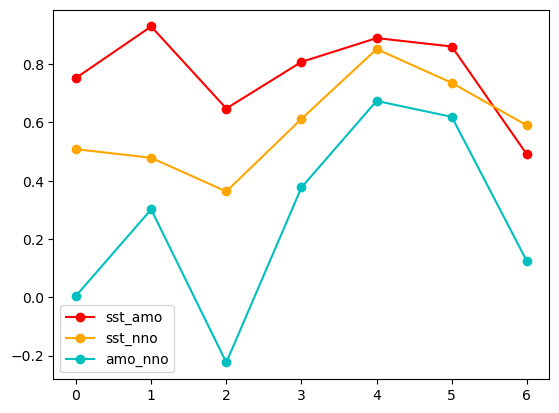

In [15]:
# sanity check
corrsdf['sst_amo'].plot(kind='line', style='-o', label='sst_amo', color='r')
corrsdf['sst_nno'].plot(kind='line', style='-o', label='sst_nno', color='orange')
corrsdf['amo_nno'].plot(kind='line', style='-o', label='amo_nno', color='c')
plt.legend()
plt.show()

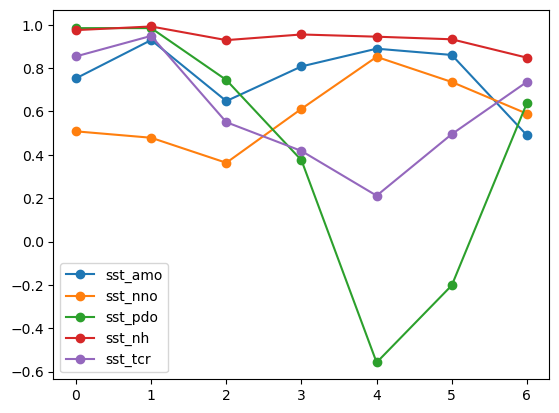

In [40]:
# all correlations from sea surface temperature
corrsdf['sst_amo'].plot(kind='line', style='-o', label='sst_amo')
corrsdf['sst_nno'].plot(kind='line', style='-o', label='sst_nno')
corrsdf['sst_pdo'].plot(kind='line', style='-o', label='sst_pdo')
corrsdf['sst_nh'].plot(kind='line', style='-o',  label='sst_nh')
corrsdf['sst_tcr'].plot(kind='line', style='-o', label='sst_tcr')
plt.legend()
plt.show()

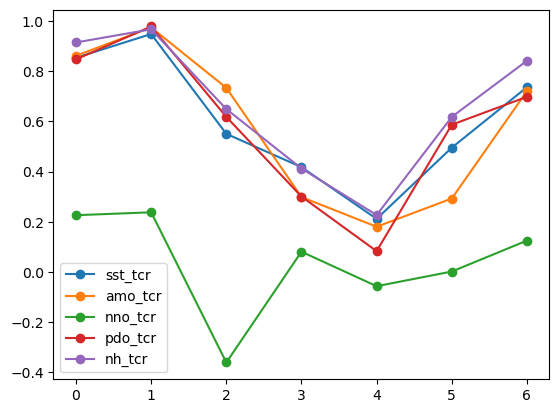

In [41]:
# plot of all predictors correlated with response
corrsdf['sst_tcr'].plot(kind='line', style='-o', label='sst_tcr')
corrsdf['amo_tcr'].plot(kind='line', style='-o', label='amo_tcr')
corrsdf['nno_tcr'].plot(kind='line', style='-o', label='nno_tcr')
corrsdf['pdo_tcr'].plot(kind='line', style='-o',  label='pdo_tcr')
corrsdf['nh_tcr'].plot(kind='line', style='-o', label='nh_tcr')
plt.legend()
plt.show()

### Partial Correlations

the partial correlation of X and Y, controlling for Z, is:

$$
r_{xy|z} = \frac{r_{xy}-r_{xz}r_{yz}}{\sqrt{1-r_{xz}^2}\sqrt{1-r_{yz}^2}}
$$

Here, we are interested in ENSO, TC | SST and ENSO, TC | AMO

In [16]:
# partial correlation of X and Y controlling for Z
def partialcorr(rxy, rxz, ryz):
    num = rxy - rxz*ryz
    denom = np.sqrt(1-rxz**2)*np.sqrt(1-ryz**2)
    
    return num/denom

In [17]:
# X = ENSO, Y = TC, Z = SST
rxy1 = corrsdf['nno_tcr']
rxz1 = corrsdf['sst_nno']
ryz1 = corrsdf['sst_tcr']

pcorrs1 = partialcorr(rxy1, rxz1, ryz1)

pcorrs1

0   -0.464654
1   -0.779653
2   -0.721717
3   -0.244068
4   -0.463514
5   -0.617580
6   -0.566758
dtype: float64

In [18]:
# X = ENSO, Y = TC, Z = AMO
rxy2 = corrsdf['nno_tcr']
rxz2 = corrsdf['amo_nno']
ryz2 = corrsdf['amo_tcr']

pcorrs2 = partialcorr(rxy2, rxz2, ryz2)
pcorrs2

0    0.437672
1   -0.264886
2   -0.297810
3   -0.036324
4   -0.245374
5   -0.239376
6    0.051680
dtype: float64

In [16]:
# call CI for all levels
ENSOTCR = np.array(corrsdf['nno_tcr'])

CIs_p1 = np.empty((7,2))
CIs_p2 = np.empty((7,2))
CIs    = np.empty((7,2))
for i in range(7):
    CIs_p1[i] = PCI(dyadic[i],pcorrs1[i],0.05,1)
    CIs_p2[i] = PCI(dyadic[i],pcorrs2[i],0.05,1)
    CIs[i]    = CI(dyadic[i],ENSOTCR[i],0.05)


lows = CIs[:, 0]
highs = CIs[:, 1]
lows_ETS = CIs_p1[:, 0]
highs_ETS = CIs_p1[:, 1]
lows_ETA = CIs_p2[:, 0]
highs_ETA = CIs_p2[:, 1]
CIs_p1

array([[-0.90206822,  0.44363783],
       [-0.92320098, -0.44519504],
       [-0.85691515, -0.49360862],
       [-0.46378736,  0.00393468],
       [-0.59007917, -0.31471267],
       [-0.68821157, -0.5353523 ],
       [-0.62287713, -0.50483498]])

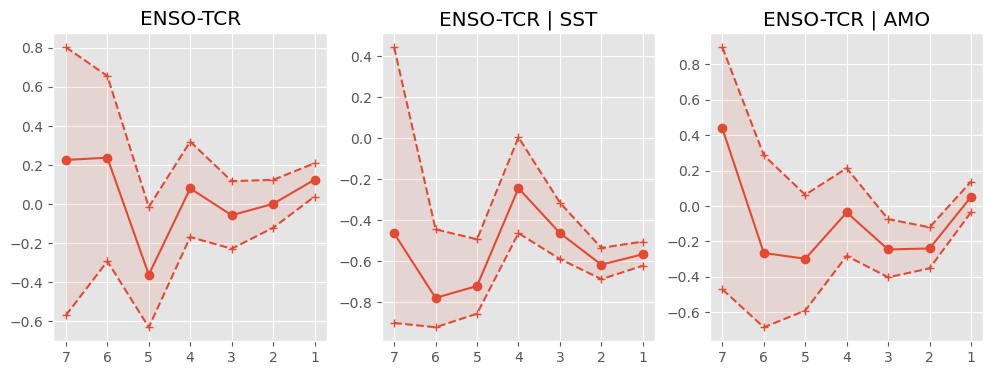

In [18]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].plot(corrsdf['nno_tcr'], 'o-')
ax[0].set_xticks(range(0,7))
ax[0].set_xticklabels(['7','6','5','4','3','2','1'])
ax[0].plot(range(0,7), lows, '+--', color='#E24A33')
ax[0].plot(range(0,7), highs, '+--', color='#E24A33')
ax[0].fill_between(range(0,7), lows, highs, alpha=.1)
ax[0].set_title('ENSO-TCR')

ax[1].plot(range(1,8), pcorrs1, 'o-')
ax[1].set_xticks(range(1,8))
ax[1].set_xticklabels(['7','6','5','4','3','2','1'])
ax[1].plot(range(1,8), lows_ETS, '+--', color='#E24A33')
ax[1].plot(range(1,8), highs_ETS, '+--', color='#E24A33')
ax[1].fill_between(range(1,8), lows_ETS, highs_ETS, alpha=.1)
ax[1].set_title('ENSO-TCR | SST')

ax[2].plot(range(1,8), pcorrs2, 'o-')
ax[2].set_xticks(range(1,8))
ax[2].set_xticklabels(['7','6','5','4','3','2','1'])
ax[2].plot(range(1,8), lows_ETA, '+--', color='#E24A33')
ax[2].plot(range(1,8), highs_ETA, '+--', color='#E24A33')
ax[2].fill_between(range(1,8), lows_ETA, highs_ETA, alpha=.1)
ax[2].set_title('ENSO-TCR | AMO')
plt.show()

# fig.savefig('GeoVisuals/PartialCorrelations.png')

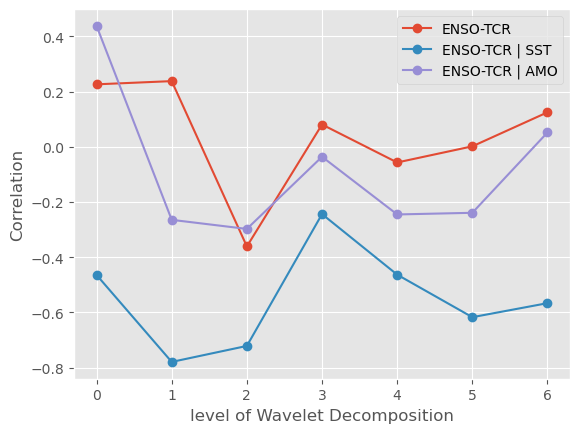

In [19]:
fig, ax = plt.subplots()
ax.plot(range(0,7), corrsdf['nno_tcr'], 'o-', label='ENSO-TCR')
ax.plot(range(0,7), pcorrs1, 'o-', label='ENSO-TCR | SST')
ax.plot(range(0,7), pcorrs2, 'o-', label='ENSO-TCR | AMO')
ax.set_xlabel('level of Wavelet Decomposition')
ax.set_ylabel('Correlation')
plt.legend()
plt.show()

### Partial Correlation with Multiple Variables

Variables of interest are:
  
1.4. pcorr(TC, ENSO | AMO, SST_MDR)  
1.5. pcorr(TC, ENSO | AMO, SST_MDR, SST_NH)  
1.6. pcorr(TC, ENSO | AMO, SST_MDR, SST_NH, PDO)  

In [8]:
# need a dataframe; each level is a different length so maybe 8 DFs, all variables, one for each level?
var_list = [sst_d,amo_d,nno_d,pdo_d,nh_d, tcr_d]
namelist = ['sst','amo','nno','pdo','nh', 'tcr']
keys = ['S_l1', 'S_l2', 'S_l3', 'S_l4', 'S_l5', 'S_l6', 'S_l7']

# no way to do this dynamically unfortunately
level7df = pd.DataFrame({'sst': sst_d[keys[0]]})
level6df = pd.DataFrame({'sst': sst_d[keys[1]]})
level5df = pd.DataFrame({'sst': sst_d[keys[2]]})
level4df = pd.DataFrame({'sst': sst_d[keys[3]]})
level3df = pd.DataFrame({'sst': sst_d[keys[4]]})
level2df = pd.DataFrame({'sst': sst_d[keys[5]]})
level1df = pd.DataFrame({'sst': sst_d[keys[6]]})

for i in range(1, 6):
    new_col_name = namelist[i]
    level7df[new_col_name] = var_list[i][keys[0]]
    level6df[new_col_name] = var_list[i][keys[1]]
    level5df[new_col_name] = var_list[i][keys[2]]
    level4df[new_col_name] = var_list[i][keys[3]]
    level3df[new_col_name] = var_list[i][keys[4]]
    level2df[new_col_name] = var_list[i][keys[5]]
    level1df[new_col_name] = var_list[i][keys[6]]
  

NameError: name 'sst_d' is not defined

In [50]:
# pcorr(TC, ENSO | AMO, SST_MDR)
l7_14 = pg.partial_corr(data=level7df, x='tcr', y='nno', covar=['amo', 'sst'])
l6_14 = pg.partial_corr(data=level6df, x='tcr', y='nno', covar=['amo', 'sst'])
l5_14 = pg.partial_corr(data=level5df, x='tcr', y='nno', covar=['amo', 'sst'])
l4_14 = pg.partial_corr(data=level4df, x='tcr', y='nno', covar=['amo', 'sst'])
l3_14 = pg.partial_corr(data=level3df, x='tcr', y='nno', covar=['amo', 'sst'])
l2_14 = pg.partial_corr(data=level2df, x='tcr', y='nno', covar=['amo', 'sst'])
l1_14 = pg.partial_corr(data=level1df, x='tcr', y='nno', covar=['amo', 'sst'])

# pcorr(TC, ENSO | AMO, SST_MDR, SST_NH)
l7_15 = pg.partial_corr(data=level7df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l6_15 = pg.partial_corr(data=level6df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l5_15 = pg.partial_corr(data=level5df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l4_15 = pg.partial_corr(data=level4df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l3_15 = pg.partial_corr(data=level3df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l2_15 = pg.partial_corr(data=level2df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])
l1_15 = pg.partial_corr(data=level1df, x='tcr', y='nno', covar=['amo', 'sst', 'nh'])

# pcorr(TC, ENSO | AMO, SST_MDR, SST_NH, PDO)
l7_16 = pg.partial_corr(data=level7df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l6_16 = pg.partial_corr(data=level6df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l5_16 = pg.partial_corr(data=level5df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l4_16 = pg.partial_corr(data=level4df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l3_16 = pg.partial_corr(data=level3df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l2_16 = pg.partial_corr(data=level2df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])
l1_16 = pg.partial_corr(data=level1df, x='tcr', y='nno', covar=['amo', 'sst', 'nh', 'pdo'])

In [51]:
tc_enso_14 = pd.concat([l7_14, l6_14, l5_14, l4_14, l3_14, l2_14, l1_14], ignore_index=True)
tc_enso_15 = pd.concat([l7_15, l6_15, l5_15, l4_15, l3_15, l2_15, l1_15], ignore_index=True)
tc_enso_16 = pd.concat([l7_16, l6_16, l5_16, l4_16, l3_16, l2_16, l1_16], ignore_index=True)

tc_enso_14

,n,r,CI95%,p-val
0,8,-0.066441,"[-0.83, 0.79]",9.004856e-01
1,16,-0.788984,"[-0.93, -0.44]",7.951788e-04
2,32,-0.550479,"[-0.76, -0.24]",1.621845e-03
3,64,-0.271897,"[-0.49, -0.02]",3.253244e-02
4,128,-0.502026,"[-0.62, -0.36]",2.112230e-09
5,256,-0.661603,"[-0.73, -0.59]",2.356571e-33
6,512,-0.549981,"[-0.61, -0.49]",1.175197e-41


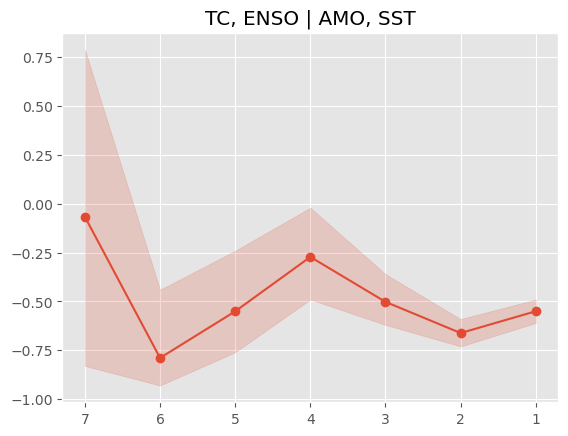

In [72]:
CI14 = np.vstack(np.array(tc_enso_14['CI95%']))
lows = CI14[:,0]
highs = CI14[:,1]

plt.style.use('ggplot')

plt.plot(tc_enso_14['r'], 'o-')
plt.xticks(range(7), ['7','6','5','4','3','2','1'])
plt.title('TC, ENSO | AMO, SST')
plt.fill_between(range(7), lows, highs, color='#E24A33', alpha=0.2)

# plt.savefig('GeoVisuals/pcorr_14.png')

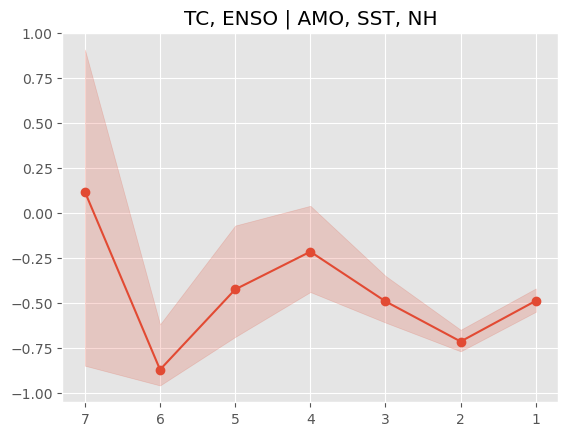

In [73]:
CI15 = np.vstack(np.array(tc_enso_15['CI95%']))
lows = CI15[:,0]
highs = CI15[:,1]

plt.plot(tc_enso_15['r'], 'o-')
plt.xticks(range(7), ['7','6','5','4','3','2','1'])
plt.title('TC, ENSO | AMO, SST, NH')
plt.fill_between(range(7), lows, highs, color='#E24A33', alpha=0.2)

# plt.savefig('GeoVisuals/pcorr_15.png')

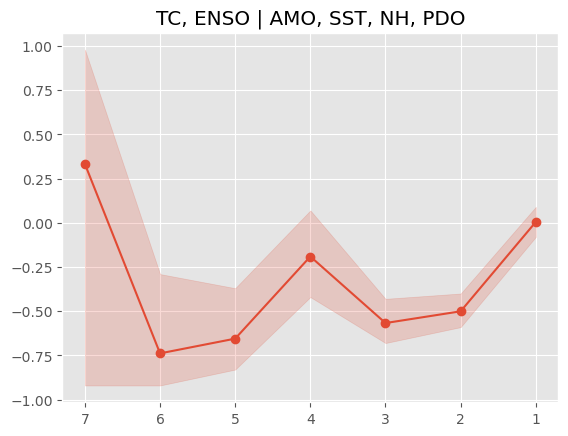

In [74]:
CI16 = np.vstack(np.array(tc_enso_16['CI95%']))
lows = CI16[:,0]
highs = CI16[:,1]

plt.plot(tc_enso_16['r'], 'o-')
plt.xticks(range(7), ['7','6','5','4','3','2','1'])
plt.title('TC, ENSO | AMO, SST, NH, PDO')
plt.fill_between(range(7), lows, highs, color='#E24A33', alpha=0.2)

# plt.savefig('GeoVisuals/pcorr_16.png')

In [78]:
# check to make sure my calculations are correct
test = pg.partial_corr(data=level7df, x='nno', y='tcr', covar=['sst'])
test

# r coefficient and CI match what I calculated by hand

,n,r,CI95%,p-val
pearson,8,-0.464654,"[-0.9, 0.44]",0.293499


In [79]:
corrsdf

,sst_amo,sst_nno,sst_pdo,sst_nh,sst_tcr,amo_nno,amo_pdo,amo_nh,amo_tcr,nno_pdo,nno_nh,nno_tcr,pdo_nh,pdo_tcr,nh_tcr
0,0.752864,0.508296,0.984398,0.975334,0.854151,0.005105,0.714056,0.857769,0.862248,0.427086,0.358944,0.226073,0.966657,0.847729,0.915176
1,0.929446,0.478752,0.984574,0.992076,0.948672,0.301559,0.954306,0.960753,0.974856,0.369032,0.457928,0.237698,0.989977,0.978823,0.967489
2,0.647926,0.363226,0.745260,0.929124,0.550590,-0.223710,0.761771,0.865788,0.734005,-0.233649,0.191283,-0.361334,0.789223,0.618302,0.649416
3,0.807854,0.612305,0.375023,0.955187,0.417776,0.377130,0.467986,0.908218,0.298556,-0.416549,0.459053,0.080487,0.516551,0.300502,0.412356
4,0.889605,0.851900,-0.557970,0.944960,0.211519,0.673822,-0.476913,0.928823,0.179996,-0.812038,0.743740,-0.057059,-0.414246,0.082609,0.226581
5,0.860714,0.736024,-0.202232,0.932967,0.495380,0.619336,-0.323552,0.870985,0.292508,-0.640509,0.631292,0.001440,-0.014061,0.587044,0.618105
6,0.490137,0.589671,0.638712,0.848205,0.736565,0.123714,0.319036,0.752533,0.720978,-0.121385,0.302582,0.124732,0.771747,0.698256,0.842166


In [92]:
# 2.1. corr(TC, AMO)
amotcr = np.array(corrsdf['amo_tcr'])

# 2.2. pcorr(TC, AMO | ENSO)
rxy1 = corrsdf['amo_tcr']
rxz1 = corrsdf['amo_nno']
ryz1 = corrsdf['nno_tcr']

pcorrs_22 = partialcorr(rxy1, rxz1, ryz1)

CIs_21 = np.empty((7,2))
CIs_22 = np.empty((7,2))
for i in range(7):
    CIs_21[i] = CI(dyadic[i],amotcr[i],0.05)
    CIs_22[i] = PCI(dyadic[i],pcorrs_22[i],0.05,1)


Text(0.5, 1.0, 'TC, AMO | ENSO')

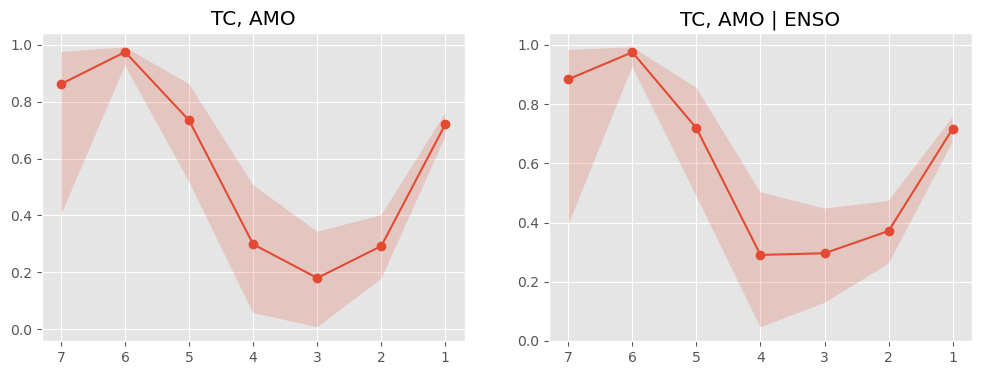

In [93]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(corrsdf['amo_tcr'], 'o-')
ax[0].set_xticks(range(0,7))
ax[0].set_xticklabels(['7','6','5','4','3','2','1'])
ax[0].fill_between(range(0,7), CIs_21[:,0], CIs_21[:,1], alpha=.2)
ax[0].set_title('TC, AMO')

ax[1].plot(pcorrs_22, 'o-')
ax[1].set_xticks(range(0,7))
ax[1].set_xticklabels(['7','6','5','4','3','2','1'])
ax[1].fill_between(range(0,7), CIs_22[:,0], CIs_22[:,1], alpha=.2)
ax[1].set_title('TC, AMO | ENSO')

# plt.savefig('GeoVisuals/pcorr_21_22.png')

In [94]:
# 3.1. corr(TC, SST_MDR)
ssttcr = np.array(corrsdf['sst_tcr'])

# 3.2. pcorr(TC, SST_MDR | ENSO)
rxy32 = corrsdf['sst_tcr']
rxz32 = corrsdf['nno_tcr']
ryz32 = corrsdf['sst_nno']

pcorrs_32 = partialcorr(rxy32, rxz32, ryz32)

CIs_31 = np.empty((7,2))
CIs_32 = np.empty((7,2))
for i in range(7):
    CIs_31[i] = CI(dyadic[i],ssttcr[i],0.05)
    CIs_32[i] = PCI(dyadic[i],pcorrs_32[i],0.05,1)


Text(0.5, 1.0, 'TC, SST | ENSO')

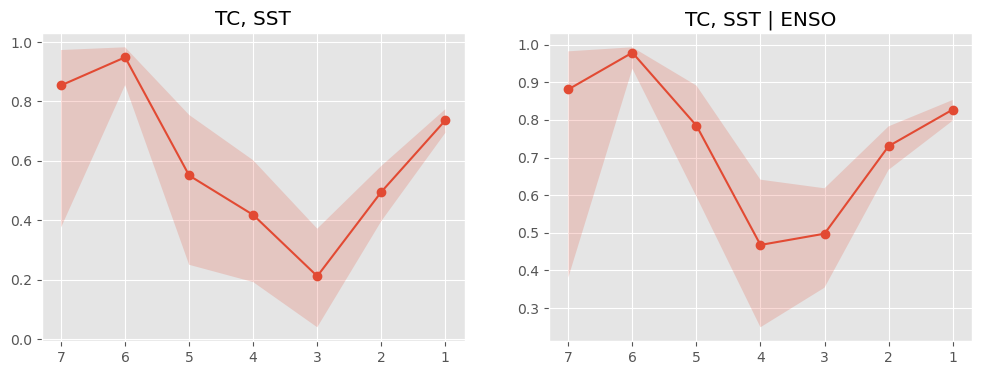

In [96]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(ssttcr, 'o-')
ax[0].set_xticks(range(0,7))
ax[0].set_xticklabels(['7','6','5','4','3','2','1'])
ax[0].fill_between(range(0,7), CIs_31[:,0], CIs_31[:,1], alpha=.2)
ax[0].set_title('TC, SST')

ax[1].plot(pcorrs_32, 'o-')
ax[1].set_xticks(range(0,7))
ax[1].set_xticklabels(['7','6','5','4','3','2','1'])
ax[1].fill_between(range(0,7), CIs_32[:,0], CIs_32[:,1], alpha=.2)
ax[1].set_title('TC, SST | ENSO')

# plt.savefig('GeoVisuals/pcorr_31_32.png')

In [97]:
# 4.1. corr(TC, SST_NH)
nhtcr = corrsdf['nh_tcr']

# 4.2. pcorr(TC, SST_NH | ENSO)
rxy42 = corrsdf['sst_nh']
rxz42 = corrsdf['sst_nno']
ryz42 = corrsdf['nno_nh']

pcorrs_42 = partialcorr(rxy42, rxz42, ryz42)

CIs_41 = np.empty((7,2))
CIs_42 = np.empty((7,2))
for i in range(7):
    CIs_41[i] = CI(dyadic[i],nhtcr[i],0.05)
    CIs_42[i] = PCI(dyadic[i],pcorrs_42[i],0.05,1)


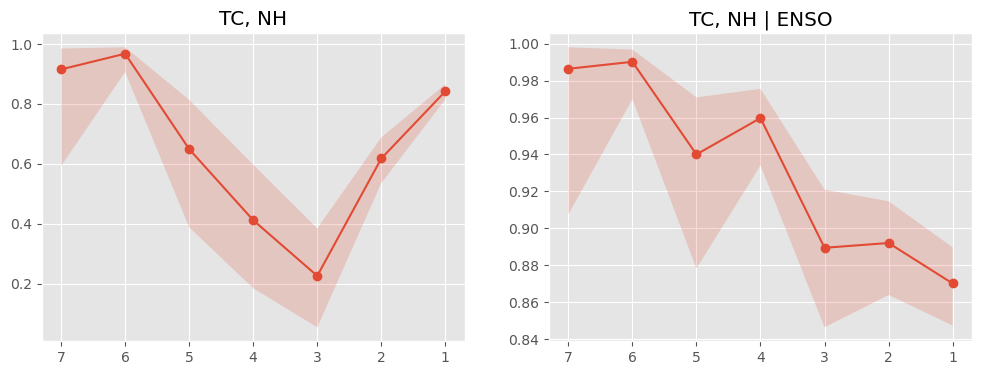

In [100]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(nhtcr, 'o-')
ax[0].set_xticks(range(0,7))
ax[0].set_xticklabels(['7','6','5','4','3','2','1'])
ax[0].fill_between(range(0,7), CIs_41[:,0], CIs_41[:,1], alpha=.2)
ax[0].set_title('TC, NH')

ax[1].plot(pcorrs_42, 'o-')
ax[1].set_xticks(range(0,7))
ax[1].set_xticklabels(['7','6','5','4','3','2','1'])
ax[1].fill_between(range(0,7), CIs_42[:,0], CIs_42[:,1], alpha=.2)
ax[1].set_title('TC, NH | ENSO')

plt.savefig('GeoVisuals/pcorr_41_42.png')

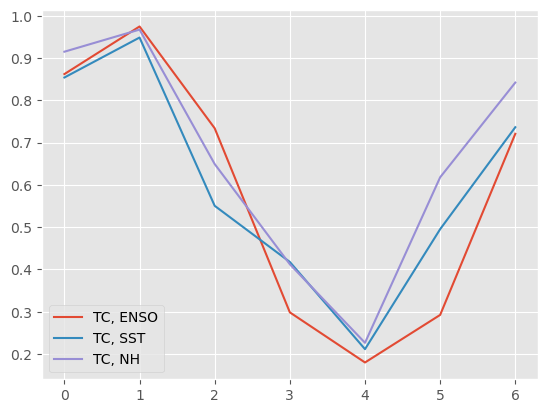

In [101]:
# a lot of those pc plots look similar
plt.plot(amotcr, label='TC, ENSO')
plt.plot(ssttcr, label='TC, SST')
plt.plot(nhtcr, label='TC, NH')
plt.legend()

### Get Heatmap Visuals for All Combinations

In [7]:
sstw = sst[326:1350, 1]
amow = amo[326:1350, 1]
nnow = nno[326:1350, 1]
pdow = pdo[326:1350, 1]
nh_w =  nh[326:1350, 1]
tcrw = tcr[326:1350, 1]

In [8]:
# we need to use NDWT for this (note: pywt.swt is non-decimated)

def decompose(data_array, wavelet='db8'):
    coeffs = pywt.swt(data_array, wavelet, 7, trim_approx=True)
    coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)
    coeffs_fin = pywt.array_to_coeffs(coeff_arr, coeff_slices, output_format='wavedec')
    
    return coeffs_fin

sst_nd = decompose(sstw)
amo_nd = decompose(amow)
nno_nd = decompose(nnow)
pdo_nd = decompose(pdow)
nh__nd = decompose(nh_w)
tcr_nd = decompose(tcrw)

In [9]:
# pad signal with mirrored ends

def pad_mirror(signal, n):
    sig_len = len(signal)
    bound = int(n/2)
    
    mirror_l = signal[0:bound][::-1]
    mirror_r = signal[sig_len-bound:sig_len][::-1]
    
    padded = np.concatenate((mirror_l, signal, mirror_r))
    return padded

In [10]:
# using centered rectangular window

def window_corr_centered(wdec1, wdec2, level, n, sig_len):
    bound = int(n/2)
    corrs = np.zeros((level, sig_len+bound))
    dcorrs = np.zeros((level, sig_len+bound))
    
    for j in range(level):
        pad_wd1 = pad_mirror(wdec1[j], n)
        pad_wd2 = pad_mirror(wdec2[j], n)
        
        window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
        window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
        
        for i in range(len(window1)):
            corrs[j,i] = np.corrcoef(window1[i], window2[i])[0,1]
            dcorrs[j,i] = dcor.distance_correlation(window1[i], window2[i], method="avl")
            
    return corrs, dcorrs

In [79]:
# test with SST-ENSO
corr_sn_50, dcorr_sn_50 = window_corr_centered(sst_nd, nno_nd, 7, 50, 1024)
corr_sn_100, dcorr_sn_100 = window_corr_centered(sst_nd, nno_nd, 7, 100, 1024)
im_corrs = np.repeat(corr_sn_50, 100, axis=0)
im_corrs100 = np.repeat(corr_sn_100, 100, axis=0)
im_dcorrs = np.repeat(dcorr_sn_50, 100, axis=0)

<function matplotlib.pyplot.show(close=None, block=None)>

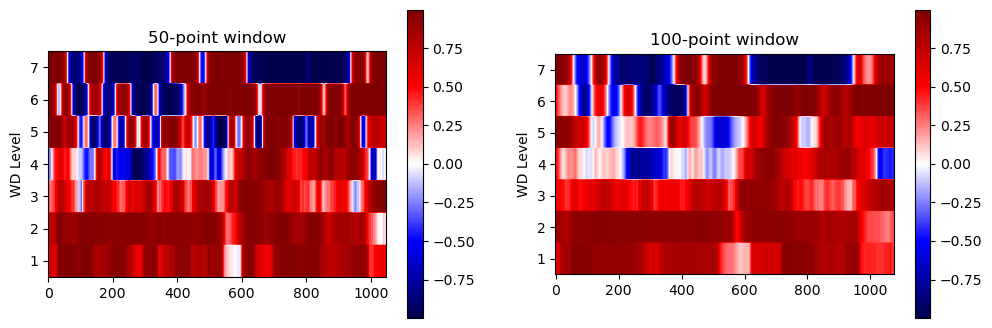

In [80]:
plt.style.use('default')
fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(im_corrs, cmap='seismic')     # original paper uses cmap='turbo'
ax[0].set_title('50-point window')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0])

im = ax[1].imshow(im_corrs100, cmap='seismic')     # original paper uses cmap='turbo'
ax[1].set_title('100-point window')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

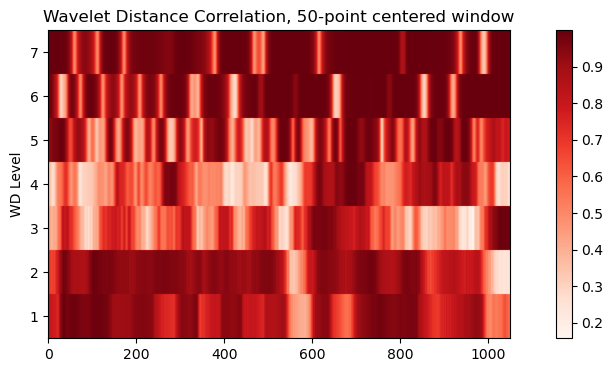

In [81]:
plt.figure(figsize=(12,4))
plt.imshow(im_dcorrs, cmap='Reds')     # to match the Pearson correlation maps
plt.title('Wavelet Distance Correlation, 50-point centered window')
plt.yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
plt.ylabel('WD Level')
plt.colorbar()
plt.show

In [23]:
# code for all combinations, pearson and distance, 50- and 100-point windows
var_list = [sst_nd,amo_nd,nno_nd,pdo_nd,nh__nd,tcr_nd]
namelist = ['sst', 'amo', 'nno', 'pdo', 'nh', 'tcr']

var_pairs = list(combinations(var_list, 2))
namepairs = list(combinations(namelist, 2))

In [24]:
import time

In [25]:
start = time.time()

corr_images_50 = {}
dcorrimages_50 = {}
corr_images_100 = {}
dcorrimages_100 = {}

for i in range(len(var_pairs)):
    corr50, dcorr50 = window_corr_centered(var_pairs[i][0], var_pairs[i][1], 7, 50, 1024)
    corr100, dcorr100 = window_corr_centered(var_pairs[i][0], var_pairs[i][1], 7, 100, 1024)
        
    im_corr50 = np.repeat(corr50, 100, axis=0)
    im_corr100 = np.repeat(corr100, 100, axis=0)
    im_dcorr50 = np.repeat(dcorr50, 100, axis=0)
    im_dcorr100 = np.repeat(dcorr100, 100, axis=0)
    
    corr_images_50[f'corr_{namepairs[i][0]}_{namepairs[i][1]}'] = im_corr50
    corr_images_100[f'corr_{namepairs[i][0]}_{namepairs[i][1]}'] = im_corr100
    dcorrimages_50[f'dcorr_{namepairs[i][0]}_{namepairs[i][1]}'] = im_dcorr50
    dcorrimages_100[f'dcorr_{namepairs[i][0]}_{namepairs[i][1]}'] = im_dcorr100
    
end = time.time()

In [26]:
print('generating all images takes ' + str(round(end-start, 2)) + ' seconds')

generating all images takes 47.37 seconds


<function matplotlib.pyplot.show(close=None, block=None)>

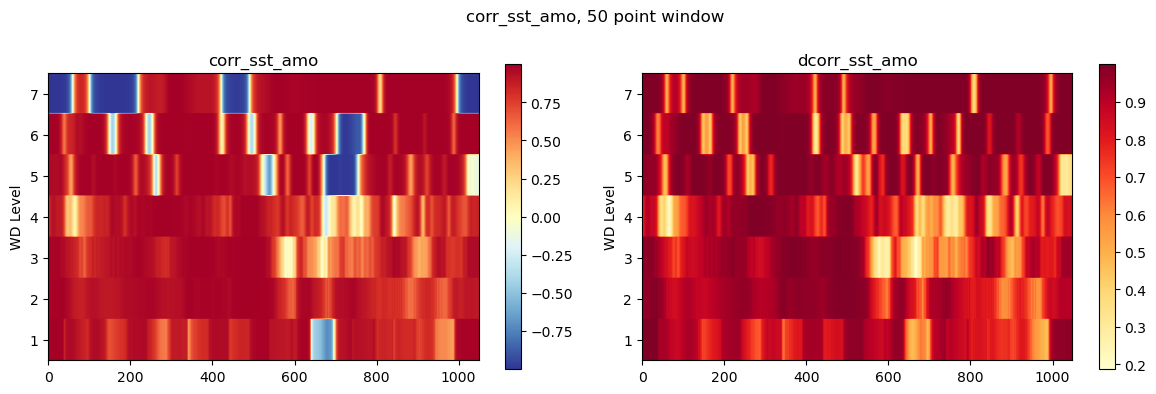

In [55]:
plt.style.use('default')
keylist = list(corr_images_50.keys())
dkeylist = list(dcorrimages_50.keys())

fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(corr_images_50[keylist[0]], cmap='RdYlBu_r')
ax[0].set_title(keylist[0])
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0], shrink=0.9)

im = ax[1].imshow(dcorrimages_50[dkeylist[0]], cmap='YlOrRd')     # to match the pearson correlation cmap
ax[1].set_title(dkeylist[0])
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1], shrink=0.9)

fig.suptitle(str(keylist[0]) + ', 50 point window')
fig.tight_layout()
plt.show

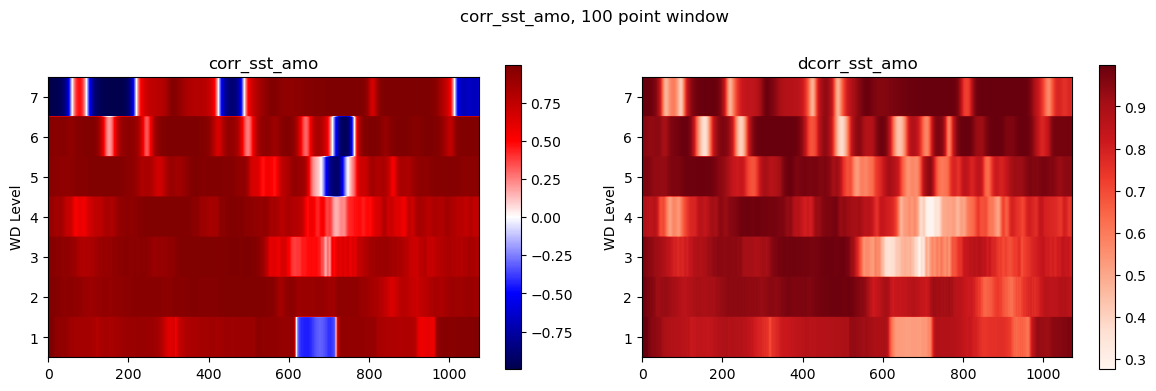

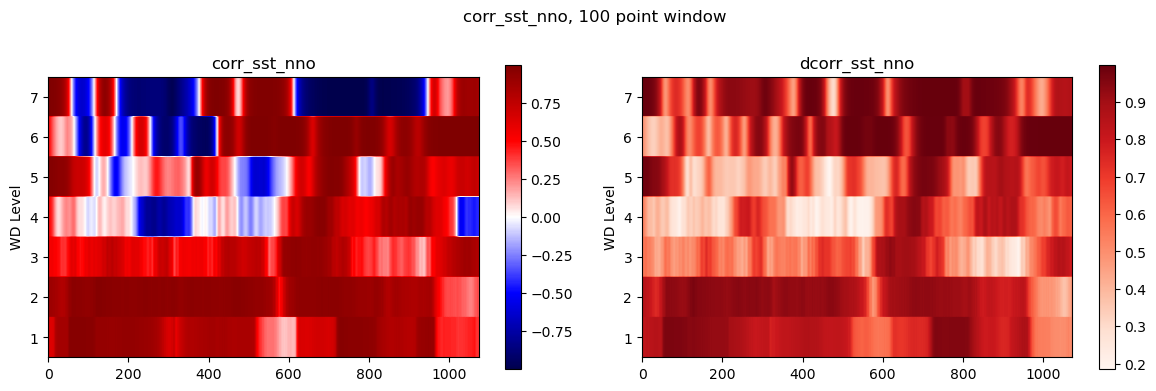

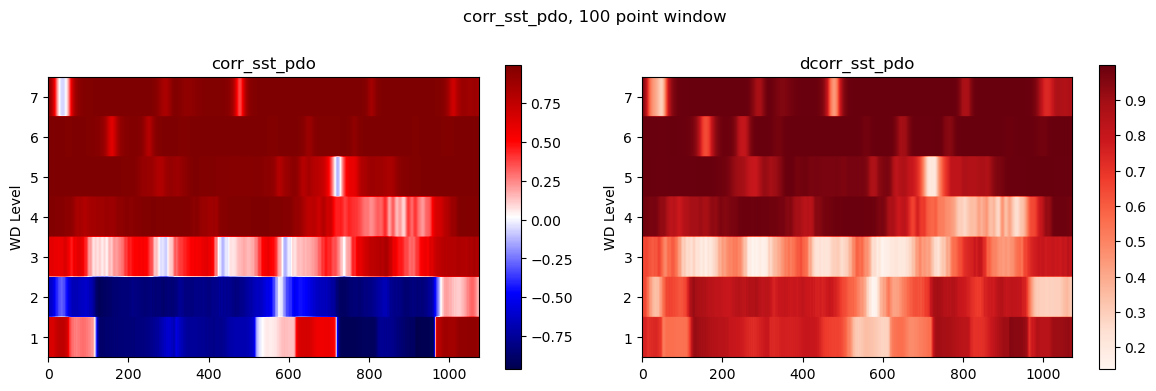

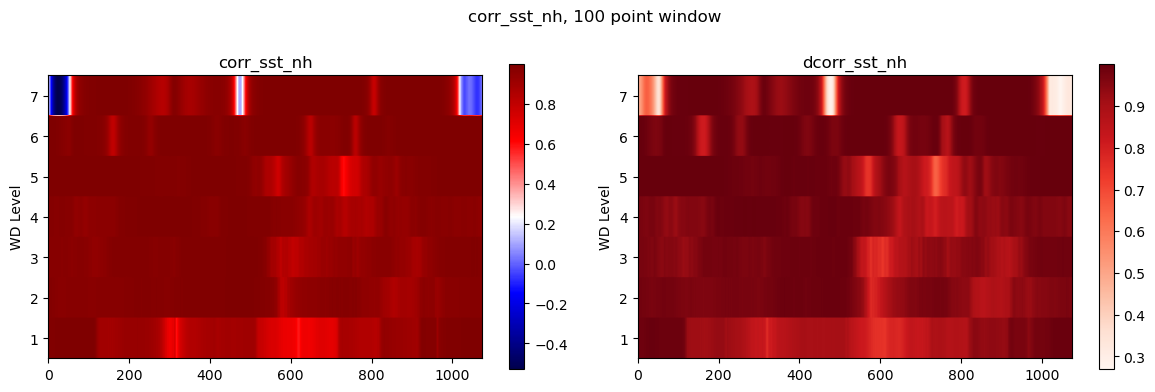

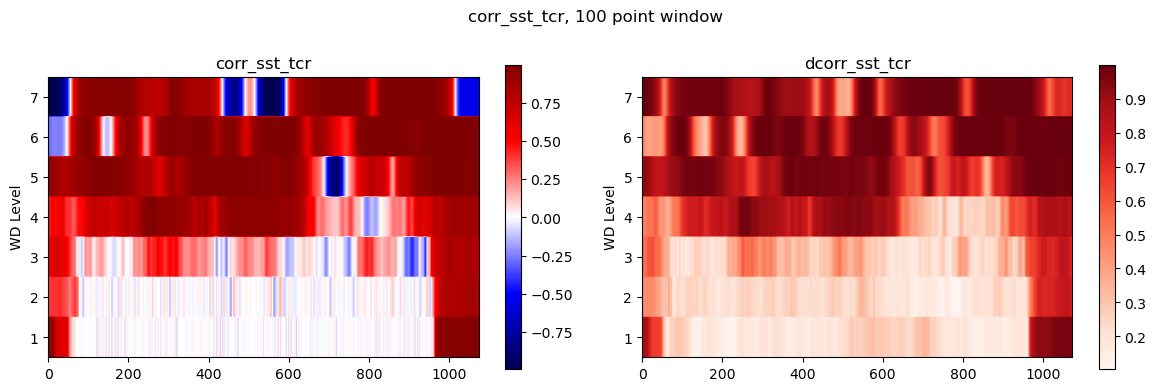

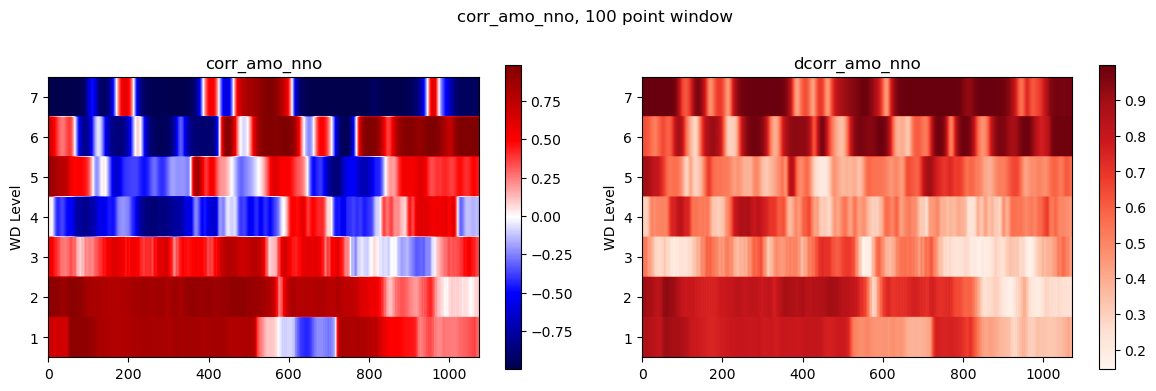

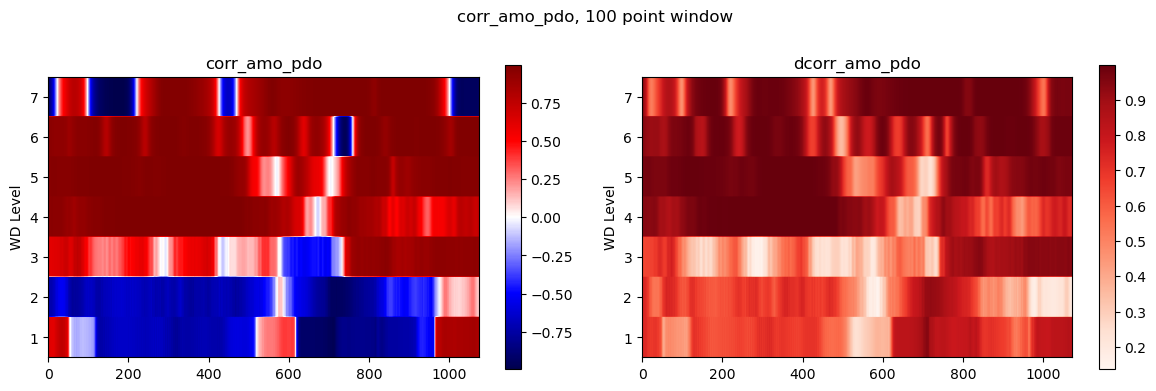

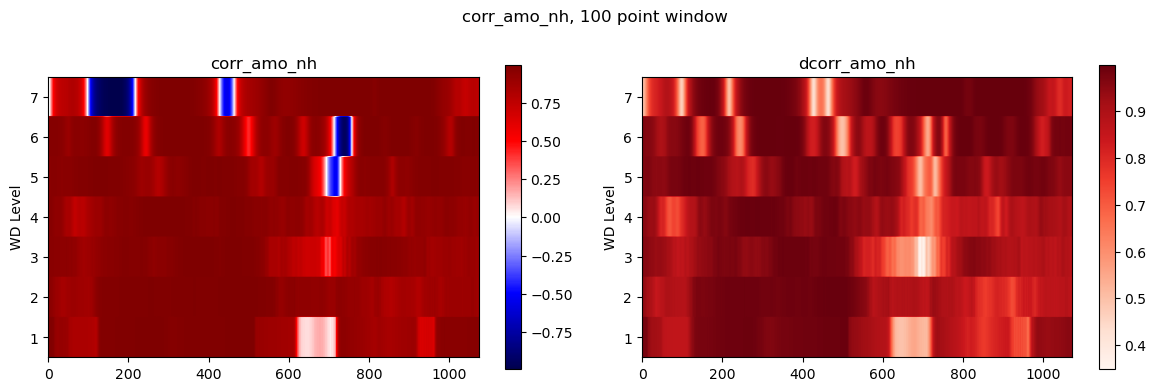

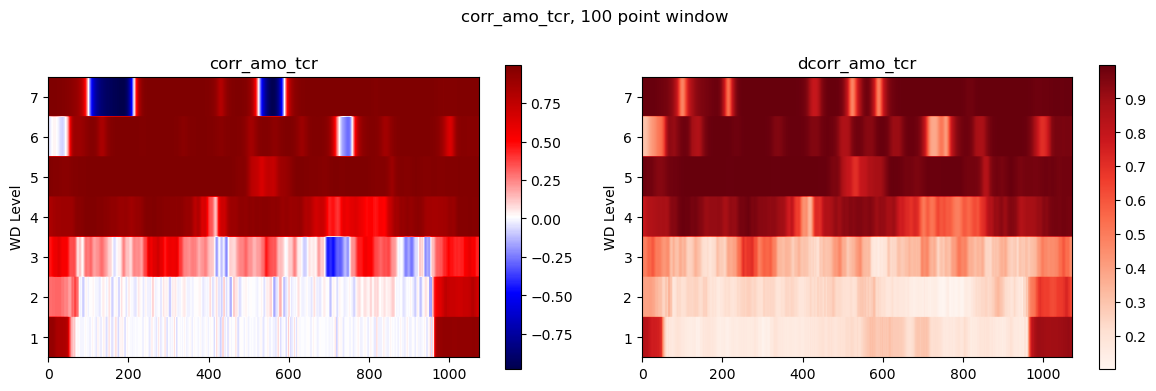

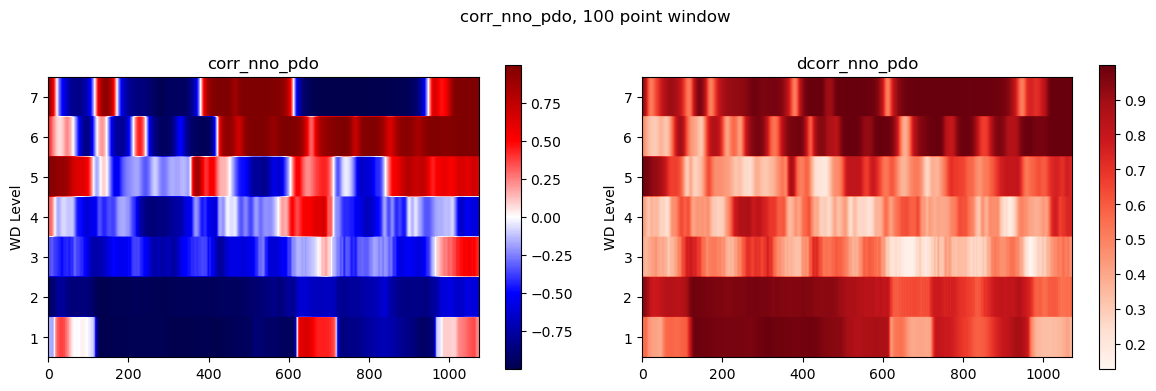

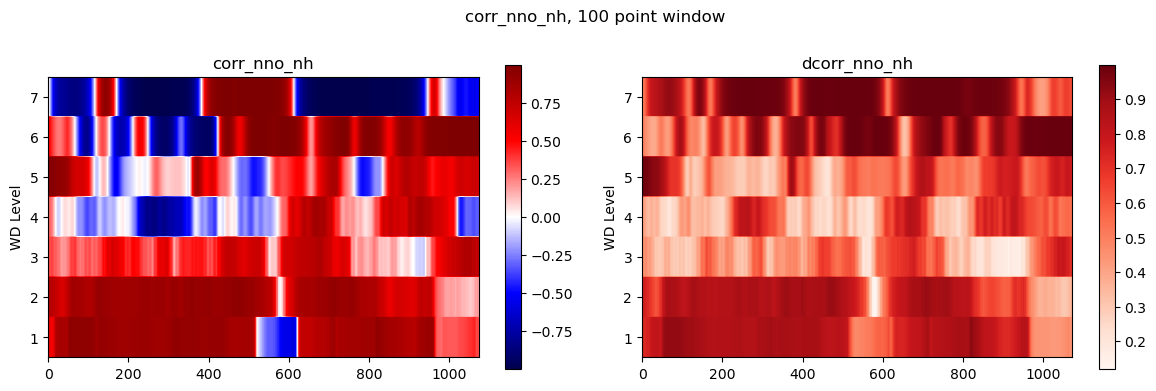

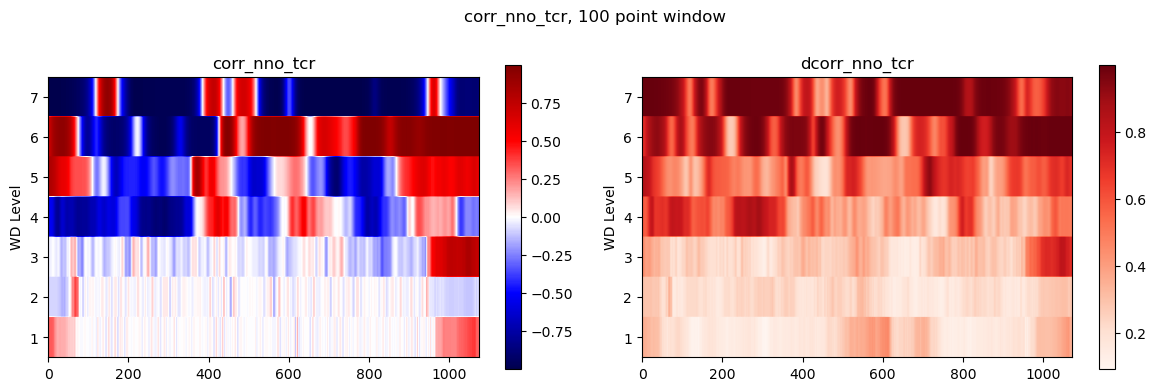

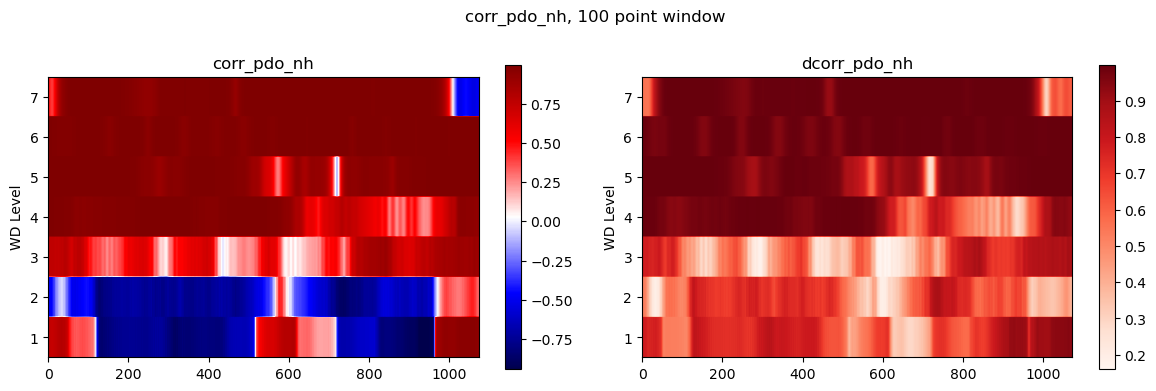

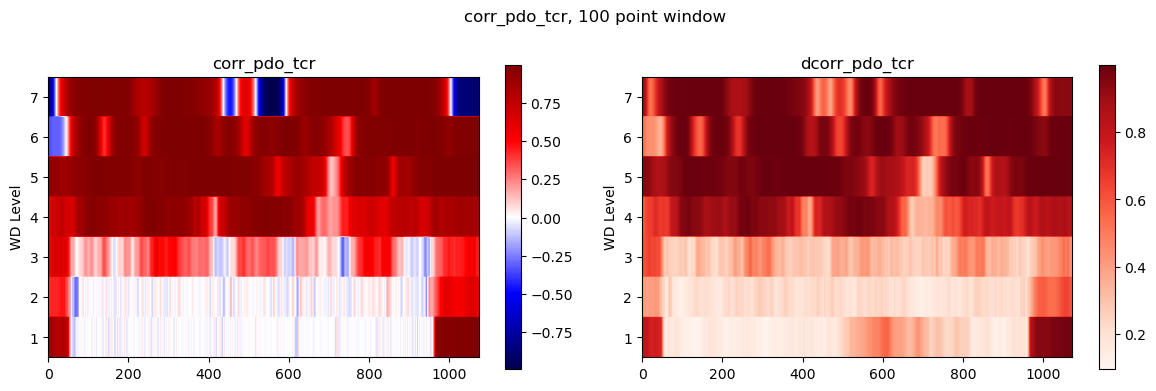

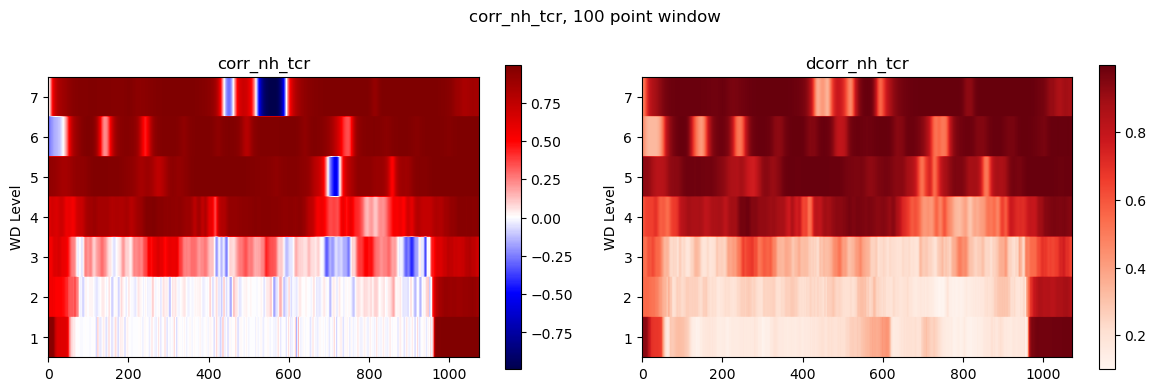

In [38]:
for i in range(len(keylist)):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    im = ax[0].imshow(corr_images_100[keylist[i]], cmap='seismic')
    ax[0].set_title(keylist[i])
    ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
    ax[0].set_ylabel('WD Level')
    fig.colorbar(im, ax=ax[0], shrink=0.9)

    im = ax[1].imshow(dcorrimages_100[dkeylist[i]], cmap='Reds')     # to match the pearson correlation cmap
    ax[1].set_title(dkeylist[i])
    ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
    ax[1].set_ylabel('WD Level')
    fig.colorbar(im, ax=ax[1], shrink=0.9)

    fig.suptitle(str(keylist[i]) + ', 100 point window')
    fig.tight_layout()
    
    fig.savefig(f'GeoVisuals/100_{keylist[i]}.png')

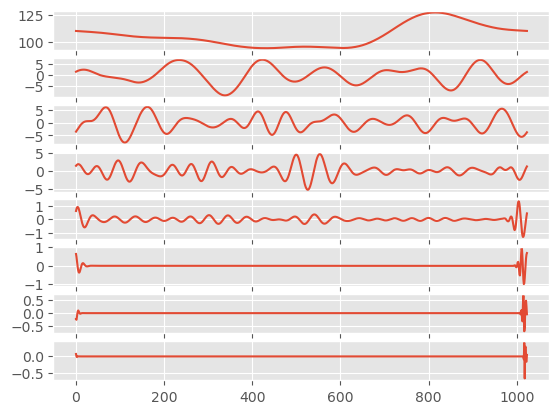

In [29]:
# what is going on with TCR?
plt.style.use('ggplot')
fig, ax = plt.subplots(8,1)
for i in range(len(tcr_nd)):
    ax[i].plot(tcr_nd[i])
plt.show()

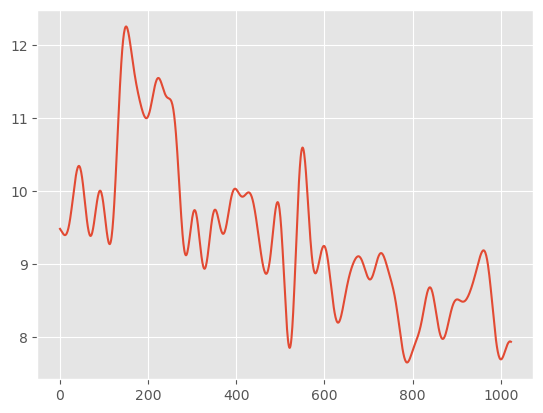

In [35]:
plt.plot(tcrw)

In [62]:
# plot partial corr heatmaps
def window_pcorr_centered(wdecX, wdecY, wdecZ, level, n, sig_len):
    bound = int(n/2)
    pcorrs = np.zeros((level, sig_len+bound))
    
    for j in range(level):
        pad_wdX = pad_mirror(wdecX[j], n)
        pad_wdY = pad_mirror(wdecY[j], n)
        pad_wdZ = pad_mirror(wdecZ[j], n)
        
        window1 = [pad_wdX[i - bound:i + bound] for i in range(bound, len(pad_wdX))]
        window2 = [pad_wdY[i - bound:i + bound] for i in range(bound, len(pad_wdY))]
        window3 = [pad_wdZ[i - bound:i + bound] for i in range(bound, len(pad_wdZ))]
        
        for i in range(len(window1)):
            rxy = np.corrcoef(window1[i], window2[i])[0,1]
            rxz = np.corrcoef(window1[i], window3[i])[0,1]
            ryz = np.corrcoef(window2[i], window3[i])[0,1]
            pcorrs[j,i] = partialcorr(rxy, rxz, ryz)
            
    return pcorrs

In [65]:
# X = ENSO, Y = TC, Z = SST
pcorr1_50 = window_pcorr_centered(nno_nd, tcr_nd, sst_nd, 7, 50, 1024)
pcorr1_100 = window_pcorr_centered(nno_nd, tcr_nd, sst_nd, 7, 100, 1024)
im_pcorr1_50 = np.repeat(pcorr1_50, 100, axis=0)
im_pcorr1_100 = np.repeat(pcorr1_100, 100, axis=0)

In [64]:
# X = ENSO, Y = TC, Z = AMO
pcorr2_50 = window_pcorr_centered(nno_nd, tcr_nd, amo_nd, 7, 50, 1024)
pcorr2_100 = window_pcorr_centered(nno_nd, tcr_nd, amo_nd, 7, 100, 1024)
im_pcorr2_50 = np.repeat(pcorr1_50, 100, axis=0)
im_pcorr2_100 = np.repeat(pcorr1_100, 100, axis=0)

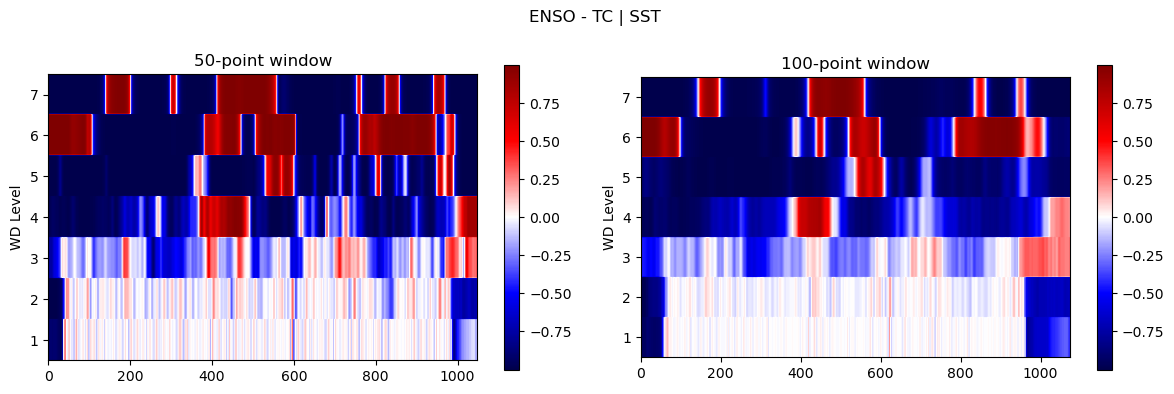

In [70]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(im_pcorr1_50, cmap='seismic')
ax[0].set_title('50-point window')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0], shrink=0.9)

im = ax[1].imshow(im_pcorr1_100, cmap='seismic')     # to match the pearson correlation cmap
ax[1].set_title('100-point window')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1], shrink=0.9)

fig.suptitle('ENSO - TC | SST')
fig.tight_layout()
plt.show

# fig.savefig(f'GeoVisuals/Pcorr1.png')

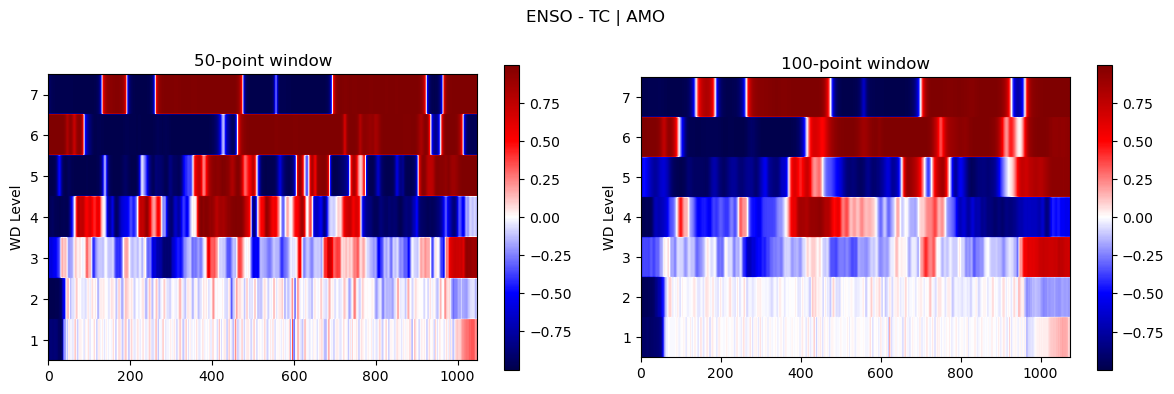

In [71]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(im_pcorr2_50, cmap='seismic')
ax[0].set_title('50-point window')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0], shrink=0.9)

im = ax[1].imshow(im_pcorr2_100, cmap='seismic')     # to match the pearson correlation cmap
ax[1].set_title('100-point window')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1], shrink=0.9)

fig.suptitle('ENSO - TC | AMO')
fig.tight_layout()
plt.show

# fig.savefig(f'GeoVisuals/Pcorr2.png')

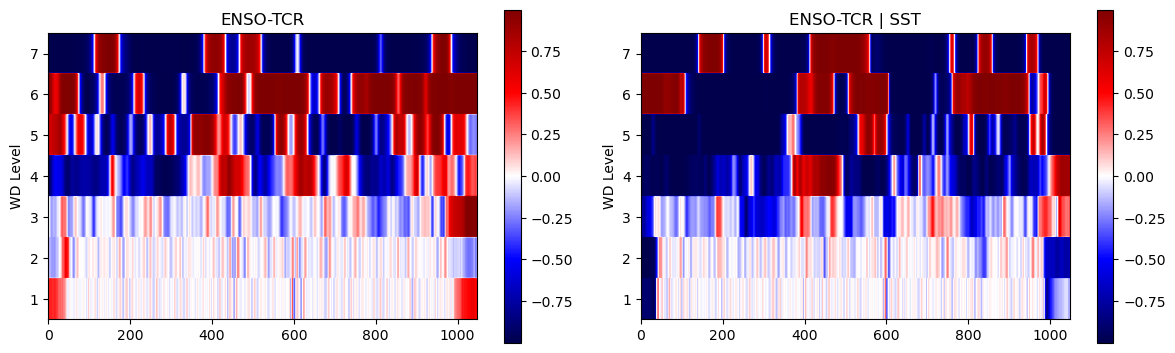

In [89]:
# comparison plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(corr_images_50['corr_nno_tcr'], cmap='seismic')
ax[0].set_title('ENSO-TCR')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0], shrink=0.9)

im = ax[1].imshow(im_pcorr1_50, cmap='seismic')     # to match the pearson correlation cmap
ax[1].set_title('ENSO-TCR | SST')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1], shrink=0.9)

fig.tight_layout()
plt.show

# fig.savefig(f'GeoVisuals/Pcorr1_comp.png')

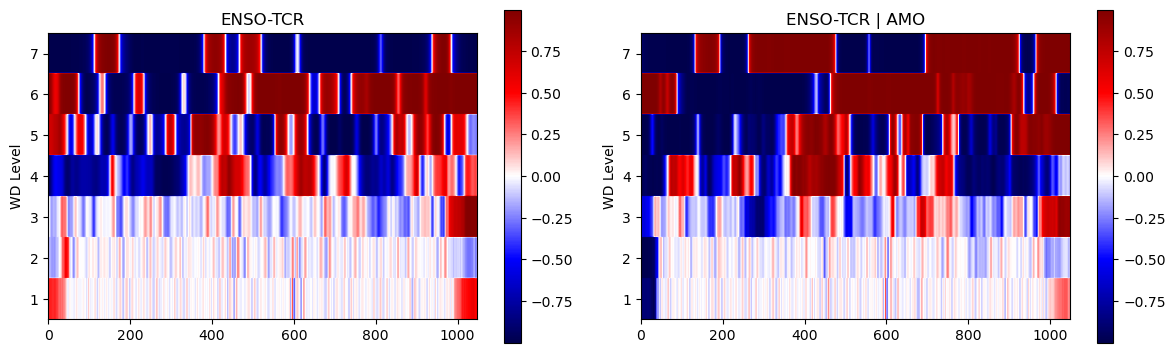

In [90]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
im = ax[0].imshow(corr_images_50['corr_nno_tcr'], cmap='seismic')
ax[0].set_title('ENSO-TCR')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[0], shrink=0.9)

im = ax[1].imshow(im_pcorr2_50, cmap='seismic')     # to match the pearson correlation cmap
ax[1].set_title('ENSO-TCR | AMO')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')
fig.colorbar(im, ax=ax[1], shrink=0.9)

fig.tight_layout()
plt.show

fig.savefig('GeoVisuals/Pcorr2_comp.png')

In [22]:
# some more partials, using just the 50-point windows

# 1.7. pcorr(TC, ENSO | SST_NH)
pcorr17 = window_pcorr_centered(tcr_nd, nno_nd, nh__nd, 7, 50, 1024)
im_pcorr17 = np.repeat(pcorr17, 100, axis=0)

# 1.8. pcorr(TC, ENSO | PDO)
pcorr18 = window_pcorr_centered(tcr_nd, nno_nd, pdo_nd, 7, 50, 1024)
im_pcorr18 = np.repeat(pcorr18, 100, axis=0)

# 2.2. pcorr(TC, AMO | ENSO)
pcorr22 = window_pcorr_centered(tcr_nd, amo_nd, nno_nd, 7, 50, 1024)
im_pcorr22 = np.repeat(pcorr22, 100, axis=0)

# 3.2. pcorr(TC, SST_MDR | ENSO)
pcorr32 = window_pcorr_centered(tcr_nd, sst_nd, nno_nd, 7, 50, 1024)
im_pcorr32 = np.repeat(pcorr32, 100, axis=0)

# 4.2. pcorr(TC, SST_NH | ENSO)
pcorr42 = window_pcorr_centered(tcr_nd, nh__nd, nno_nd, 7, 50, 1024)
im_pcorr42 = np.repeat(pcorr42, 100, axis=0)


In [36]:
keylist1 = ['corr_nno_tcr', 'corr_nno_tcr', 'corr_amo_tcr', 'corr_sst_tcr', 'corr_nh_tcr']
titles1  = ['TC, ENSO', 'TC, ENSO', 'TC, AMO', 'TC, SST', 'TC, NH']
keylist2 = [im_pcorr17, im_pcorr18, im_pcorr22, im_pcorr32, im_pcorr42]
titles2  = ['TC, ENSO | NH', 'TC, ENSO | PDO', 'TC, AMO | ENSO', 'TC, SST | ENSO', 'TC, NH | ENSO']

fignames = ['17', '18', '21_22', '31_32', '41_42']

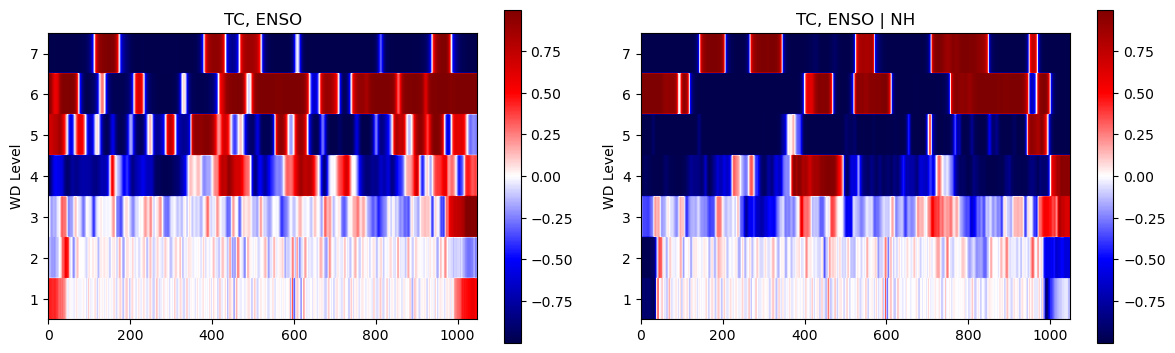

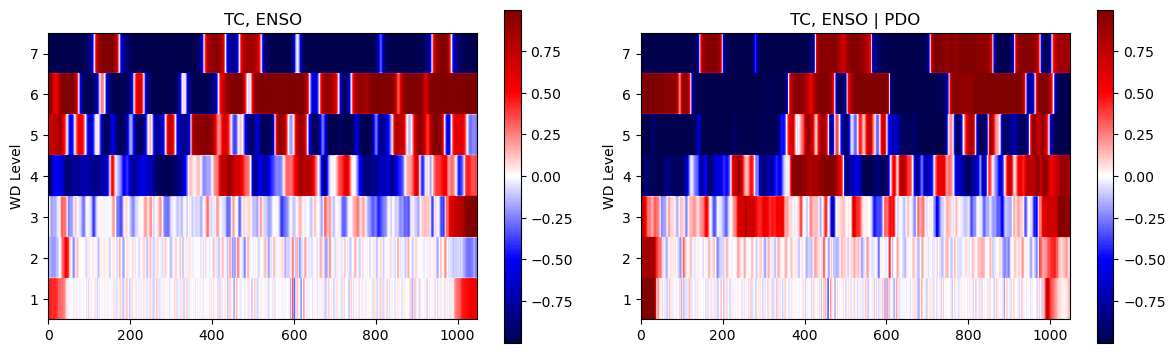

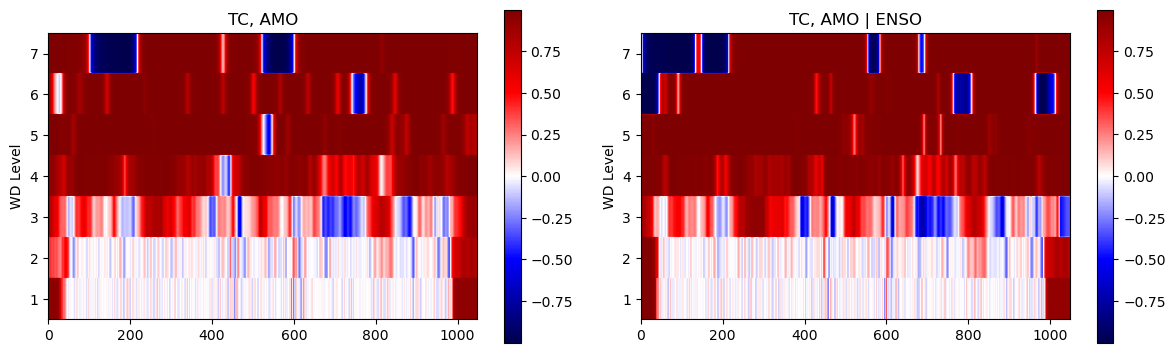

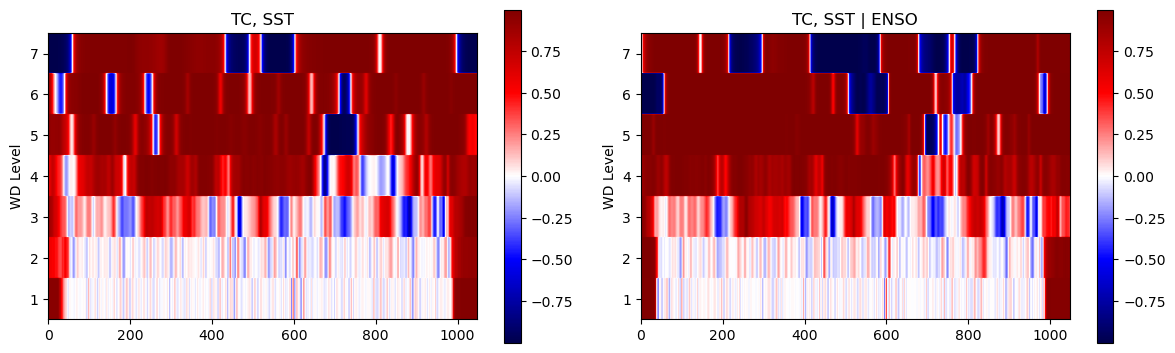

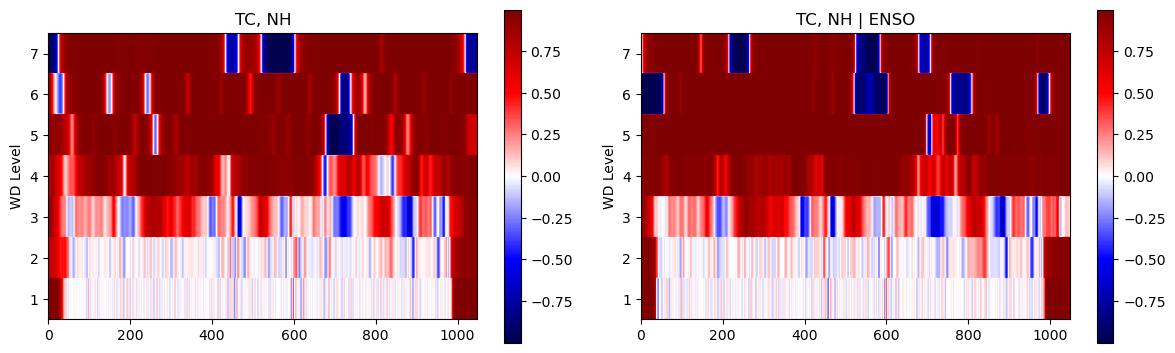

In [37]:
# comparison plots
for i in range(len(keylist1)):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    im = ax[0].imshow(corr_images_50[keylist1[i]], cmap='seismic')
    ax[0].set_title(titles1[i])
    ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
    ax[0].set_ylabel('WD Level')
    fig.colorbar(im, ax=ax[0], shrink=0.9)

    im = ax[1].imshow(keylist2[i], cmap='seismic')     # to match the pearson correlation cmap
    ax[1].set_title(titles2[i])
    ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
    ax[1].set_ylabel('WD Level')
    fig.colorbar(im, ax=ax[1], shrink=0.9)

    fig.tight_layout()
    
    fig.savefig(f'GeoVisuals/img_{fignames[i]}.png')

### Partial Correlation with Multiple Controls

In [11]:
sstw = sst[326:1350, 1]
amow = amo[326:1350, 1]
nnow = nno[326:1350, 1]
pdow = pdo[326:1350, 1]
nh_w =  nh[326:1350, 1]
tcrw = tcr[326:1350, 1]

In [12]:
# we need to use NDWT for this (note: pywt.swt is non-decimated)

def decompose(data_array, wavelet='db8'):
    coeffs = pywt.swt(data_array, wavelet, 7, trim_approx=True)
    coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)
    coeffs_fin = pywt.array_to_coeffs(coeff_arr, coeff_slices, output_format='wavedec')
    
    return coeffs_fin

sst_nd = decompose(sstw)
amo_nd = decompose(amow)
nno_nd = decompose(nnow)
pdo_nd = decompose(pdow)
nh__nd = decompose(nh_w)
tcr_nd = decompose(tcrw)

To get the partial correlation of $X$ and $Y$ given vector of independent variables $\mathbf{Z}$, the following steps are performed:  

1. regress $X$ on $\mathbf{Z}$ and get the residuals $e_X$  
2. regress $Y$ on $\mathbf{Z}$ and get the residuals $e_Y$  
3. partial correlation $\rho_{X,Y | \mathbf{Z}}$ is then the correlation between $e_X$ and $e_Y$

In [15]:
# just gonna do this by hand 
from sklearn.linear_model import LinearRegression

def pcorr_mv(x,y,z):
    lr1 = LinearRegression().fit(z, x)
    lr2 = LinearRegression().fit(z, y)

    residX = x - lr1.predict(z)
    residY = y - lr2.predict(z)

    corr = np.corrcoef(residX, residY)[0,1]
    return corr

In [58]:
# test above function
bound = 25
# pad mirror signals (test with level 7 only)
pad_wd1 = pad_mirror(tcr_nd[6], 50)
pad_wd2 = pad_mirror(nno_nd[6], 50)
pad_wd3 = pad_mirror(amo_nd[6], 50)
pad_wd4 = pad_mirror(sst_nd[6], 50)
    
window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
window3 = [pad_wd3[i - bound:i + bound] for i in range(bound, len(pad_wd3))]
window4 = [pad_wd4[i - bound:i + bound] for i in range(bound, len(pad_wd4))]

Z = np.transpose(np.vstack((window3[0], window4[0])))
test = pcorr_mv(window1[0], window2[0],Z)

# check above result against pingouin method
data = pd.DataFrame({'tcr':window1[0], 'nno':window2[0], 'amo':window3[0], 'sst':window4[0]})
testpc = pg.partial_corr(data=data, x='tcr', y='nno', covar=['amo', 'sst'])

print(test, testpc['r'])

# it works!

-0.8628678189017979 pearson   -0.862868
Name: r, dtype: float64


In [17]:
def window_pcorrmv_centered(wdec1, wdec2, wdec3, wdec4, level, n, sig_len, wdec5=None, wdec6=None, npred=2):
    bound = int(n/2)
    pcorrs = np.zeros((level, sig_len+bound))
    
    for j in range(level):
        pad_wd1 = pad_mirror(wdec1[j], n)
        pad_wd2 = pad_mirror(wdec2[j], n)
        pad_wd3 = pad_mirror(wdec3[j], n)
        pad_wd4 = pad_mirror(wdec4[j], n)
        
        if wdec5 is not None:
            pad_wd5 = pad_mirror(wdec5[j], n)
            
        if wdec6 is not None:
            pad_wd6 = pad_mirror(wdec6[j], n)
        
        window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
        window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
        window3 = [pad_wd3[i - bound:i + bound] for i in range(bound, len(pad_wd3))]
        window4 = [pad_wd4[i - bound:i + bound] for i in range(bound, len(pad_wd4))]
        
        if wdec5 is not None:
            window5 = [pad_wd5[i - bound:i + bound] for i in range(bound, len(pad_wd5))]
            
        if wdec6 is not None:
            window6 = [pad_wd6[i - bound:i + bound] for i in range(bound, len(pad_wd6))]
        
        for i in range(len(window1)):
            if npred == 3:
                Z = np.transpose(np.vstack((window3[i], window4[i], window5[i])))
            elif npred == 4:
                Z = np.transpose(np.vstack((window3[i], window4[i], window5[i], window6[i])))
            else:
                Z = np.transpose(np.vstack((window3[i], window4[i])))
                
        pcorrs[j,i] = pcorr_mv(window1[i], window2[i], Z)
            
    return pcorrs

In [20]:
# 1.4. pcorr(TC, ENSO | AMO, SST_MDR)
bound = 25
pcorr_14 = np.zeros((7, 1024+bound))
# pad mirror signals (test with level 7 only)
for j in range(7):
    pad_wd1 = pad_mirror(tcr_nd[j], 50)
    pad_wd2 = pad_mirror(nno_nd[j], 50)
    pad_wd3 = pad_mirror(amo_nd[j], 50)
    pad_wd4 = pad_mirror(sst_nd[j], 50)
    
    window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
    window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
    window3 = [pad_wd3[i - bound:i + bound] for i in range(bound, len(pad_wd3))]
    window4 = [pad_wd4[i - bound:i + bound] for i in range(bound, len(pad_wd4))]

    for i in range(len(window1)):
        Z = np.transpose(np.vstack((window3[i], window4[i])))
        pcorr_14[j,i] = pcorr_mv(window1[i], window2[i],Z)

im_pcorr14 = np.repeat(pcorr_14, 100, axis=0)

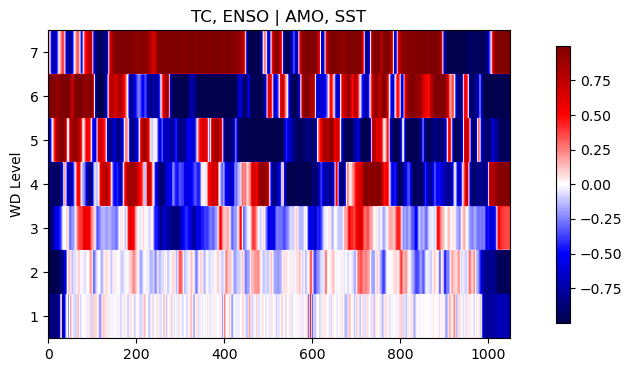

In [30]:
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(im_pcorr14, cmap='seismic')
ax.set_title('TC, ENSO | AMO, SST')
ax.set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax.set_ylabel('WD Level')
fig.colorbar(im, ax=ax, shrink=0.9)
plt.show()

# fig.savefig(f'GeoVisuals/img_14.png')

In [25]:
# 1.5. pcorr(TC, ENSO | AMO, SST_MDR, SST_NH)
pcorr_15 = np.zeros((7, 1024+bound))
# pad mirror signals (test with level 7 only)
for j in range(7):
    pad_wd1 = pad_mirror(tcr_nd[j], 50)
    pad_wd2 = pad_mirror(nno_nd[j], 50)
    pad_wd3 = pad_mirror(amo_nd[j], 50)
    pad_wd4 = pad_mirror(sst_nd[j], 50)
    pad_wd5 = pad_mirror(nh__nd[j], 50)
    
    window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
    window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
    window3 = [pad_wd3[i - bound:i + bound] for i in range(bound, len(pad_wd3))]
    window4 = [pad_wd4[i - bound:i + bound] for i in range(bound, len(pad_wd4))]
    window5 = [pad_wd5[i - bound:i + bound] for i in range(bound, len(pad_wd5))]

    for i in range(len(window1)):
        Z = np.transpose(np.vstack((window3[i], window4[i], window5[i])))
        pcorr_15[j,i] = pcorr_mv(window1[i], window2[i],Z)

im_pcorr15 = np.repeat(pcorr_15, 100, axis=0)

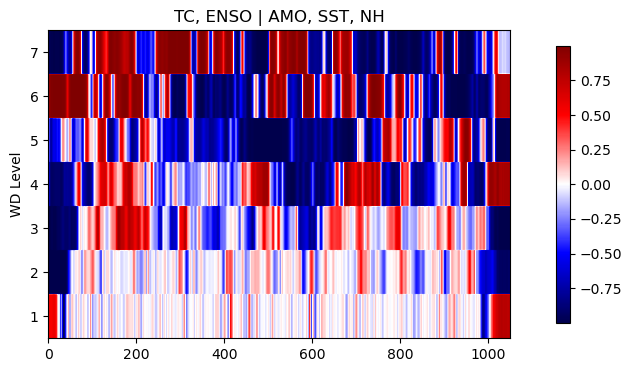

In [31]:
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(im_pcorr15, cmap='seismic')
ax.set_title('TC, ENSO | AMO, SST, NH')
ax.set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax.set_ylabel('WD Level')
fig.colorbar(im, ax=ax, shrink=0.9)
plt.show()

# fig.savefig(f'GeoVisuals/img_15.png')

In [28]:
# 1.6. pcorr(TC, ENSO | AMO, SST_MDR, SST_NH, PDO)
pcorr_16 = np.zeros((7, 1024+bound))
# pad mirror signals (test with level 7 only)
for j in range(7):
    pad_wd1 = pad_mirror(tcr_nd[j], 50)
    pad_wd2 = pad_mirror(nno_nd[j], 50)
    pad_wd3 = pad_mirror(amo_nd[j], 50)
    pad_wd4 = pad_mirror(sst_nd[j], 50)
    pad_wd5 = pad_mirror(nh__nd[j], 50)
    pad_wd6 = pad_mirror(pdo_nd[j], 50)
    
    window1 = [pad_wd1[i - bound:i + bound] for i in range(bound, len(pad_wd1))]
    window2 = [pad_wd2[i - bound:i + bound] for i in range(bound, len(pad_wd2))]
    window3 = [pad_wd3[i - bound:i + bound] for i in range(bound, len(pad_wd3))]
    window4 = [pad_wd4[i - bound:i + bound] for i in range(bound, len(pad_wd4))]
    window5 = [pad_wd5[i - bound:i + bound] for i in range(bound, len(pad_wd5))]
    window6 = [pad_wd6[i - bound:i + bound] for i in range(bound, len(pad_wd6))]

    for i in range(len(window1)):
        Z = np.transpose(np.vstack((window3[i], window4[i], window5[i], window6[i])))
        pcorr_16[j,i] = pcorr_mv(window1[i], window2[i],Z)

im_pcorr16 = np.repeat(pcorr_16, 100, axis=0)

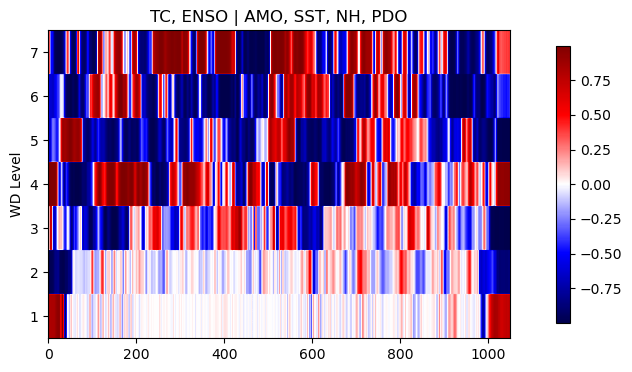

In [32]:
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(im_pcorr16, cmap='seismic')
ax.set_title('TC, ENSO | AMO, SST, NH, PDO')
ax.set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax.set_ylabel('WD Level')
fig.colorbar(im, ax=ax, shrink=0.9)
plt.show()

# fig.savefig(f'GeoVisuals/img_16.png')

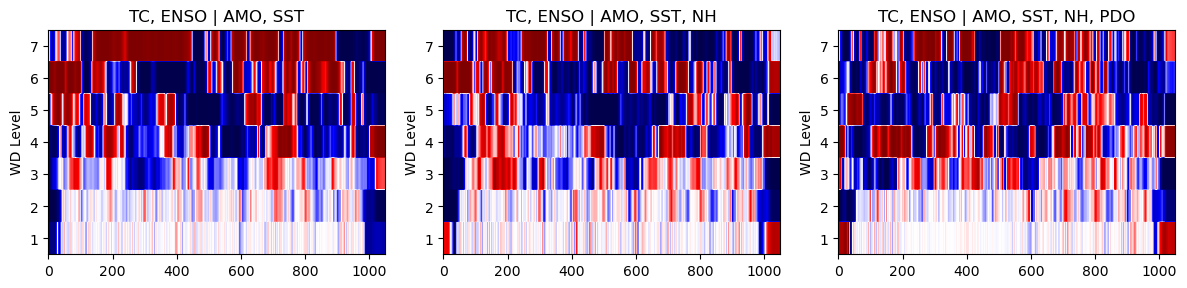

In [35]:
# compare all 3
fig, ax = plt.subplots(1,3, figsize=(12,8))
ax[0].imshow(im_pcorr14, cmap='seismic')
ax[0].set_title('TC, ENSO | AMO, SST')
ax[0].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[0].set_ylabel('WD Level')

ax[1].imshow(im_pcorr15, cmap='seismic')     
ax[1].set_title('TC, ENSO | AMO, SST, NH')
ax[1].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[1].set_ylabel('WD Level')

ax[2].imshow(im_pcorr16, cmap='seismic')     
ax[2].set_title('TC, ENSO | AMO, SST, NH, PDO')
ax[2].set_yticks([50,150,250,350, 450, 550, 650], ['7', '6', '5', '4', '3', '2', '1'])
ax[2].set_ylabel('WD Level')

fig.tight_layout()
plt.show()

# fig.savefig(f'GeoVisuals/img_14_15_16.png')

### Try Different Wavelet Bases

In [19]:
# these variables are universal:
dyadic = [8, 16, 32, 64, 128, 256, 512, 1024]
l = 7
n = 1024

namelist = ['sst', 'amo', 'nno', 'pdo', 'nh', 'tcr']
namepairs = list(combinations(namelist, 2))

In [20]:
def diff_filters(wavelet, taps):
    # get all wavelet decomps
    sst_h = wdecomp(sstw, n, l, wavelet, taps, dyadic)
    amo_h = wdecomp(amow, n, l, wavelet, taps, dyadic)
    nno_h = wdecomp(nnow, n, l, wavelet, taps, dyadic)
    pdo_h = wdecomp(pdow, n, l, wavelet, taps, dyadic)
    nh_h  = wdecomp(nh_w, n, l, wavelet, taps, dyadic)
    tcr_h = wdecomp(tcrw, n, l, wavelet, taps, dyadic)

    var_list = [sst_h,amo_h,nno_h,pdo_h,nh_h, tcr_h]
    var_pairs = list(combinations(var_list, 2))
    
    allcorrs = []
    distcorrs = []

    for j in range(len(var_pairs)):
        alist = var_pairs[j][0][0]
        a_decomps = var_pairs[j][0][1]
        blist = var_pairs[j][1][0]
        b_decomps = var_pairs[j][1][1]
        corrs = getcorrs(alist, a_decomps, blist, b_decomps)
        dcorrs = getdcorrs(alist, a_decomps, blist, b_decomps)
        allcorrs.append(corrs)
        distcorrs.append(dcorrs)
        
    corrdf = pd.DataFrame({'sst_amo': allcorrs[0],})
    dcorrdf = pd.DataFrame({'sst_amo': distcorrs[0],})

    for i in range(1, len(var_pairs)):
        new_col_name = namepairs[i][0] + '_' + namepairs[i][1]
        corrdf[new_col_name] = allcorrs[i]
        dcorrdf[new_col_name] = distcorrs[i]
        
    return corrdf, dcorrdf

#### Haar

In [21]:
haardf, haardistdf = diff_filters('Haar', 2)

#### Daubechies 4

In [22]:
d4df, d4distdf = diff_filters('Daubechies', 4)

#### Symmlet

In [30]:
# note: symmlet 4 has 8 taps
symmdf, symdistdf = diff_filters('Symmlet', 4)

#### Coiflet 6

In [29]:
# note: Coiflet 1 has 6 taps
coifdf, coifdistdf = diff_filters('Coiflet', 1)

### Visualize Wavelet Differences

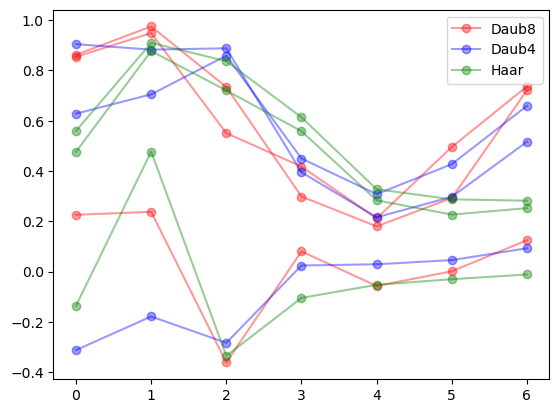

In [25]:
# visuals, 3 examples

# plot original (Daub8)
corrsdf['sst_tcr'].plot(kind='line', style='-o', color='r', alpha=0.4, label='Daub8')
corrsdf['amo_tcr'].plot(kind='line', style='-o', color='r', alpha=0.4, label='')
corrsdf['nno_tcr'].plot(kind='line', style='-o', color='r', alpha=0.4, label='')

# plot Daub4
d4df['sst_tcr'].plot(kind='line', style='-o', color='b', alpha=0.4, label='Daub4')
d4df['amo_tcr'].plot(kind='line', style='-o', color='b', alpha=0.4, label='')
d4df['nno_tcr'].plot(kind='line', style='-o', color='b', alpha=0.4, label='')

#plot Haar
haardf['sst_tcr'].plot(kind='line', style='-o', color='g', alpha=0.4, label='Haar')
haardf['amo_tcr'].plot(kind='line', style='-o', color='g', alpha=0.4, label='')
haardf['nno_tcr'].plot(kind='line', style='-o', color='g', alpha=0.4, label='')

plt.legend()
plt.show()

### Compare with Distance Correlation

<Axes: >

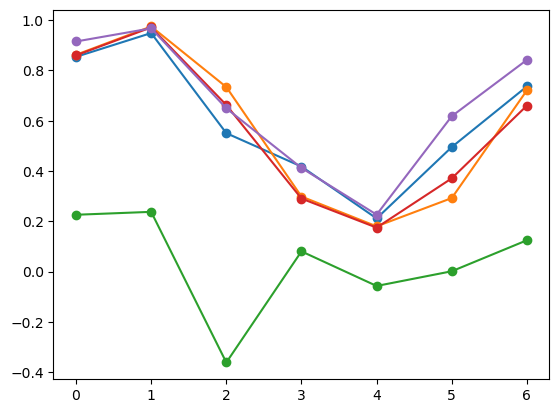

In [26]:
corrsdf['sst_tcr'].plot(kind='line', style='-o', label='sst_tcr')
corrsdf['amo_tcr'].plot(kind='line', style='-o', label='amo_tcr')
corrsdf['nno_tcr'].plot(kind='line', style='-o', label='nno_tcr')
distcorrsdf['pdo_tcr'].plot(kind='line', style='-o',  label='pdo_tcr')
corrsdf['nh_tcr'].plot(kind='line', style='-o', label='nh_tcr')

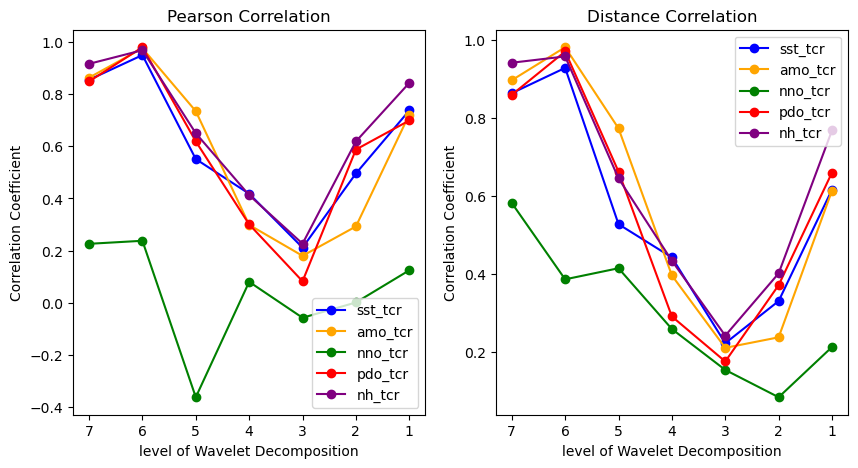

In [27]:
# using same original filter (Daub8)
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10, 5)
ax[0].plot(range(1,8), corrsdf['sst_tcr'], 'o-', color='b', label='sst_tcr')
ax[0].plot(range(1,8), corrsdf['amo_tcr'], 'o-', color='orange', label='amo_tcr')
ax[0].plot(range(1,8), corrsdf['nno_tcr'], 'o-', color='green', label='nno_tcr')
ax[0].plot(range(1,8), corrsdf['pdo_tcr'], 'o-', color='r', label='pdo_tcr')
ax[0].plot(range(1,8), corrsdf['nh_tcr'], 'o-', color='purple', label='nh_tcr')
ax[0].set_xticks(range(1,8), [7,6,5,4,3,2,1])
ax[0].set_xlabel('level of Wavelet Decomposition')
ax[0].set_ylabel('Correlation Coefficient')
ax[0].set_title('Pearson Correlation')
ax[0].legend(loc='lower right')

ax[1].plot(range(1,8), distcorrsdf['sst_tcr'], 'o-', color='b', label='sst_tcr')
ax[1].plot(range(1,8), distcorrsdf['amo_tcr'], 'o-', color='orange', label='amo_tcr')
ax[1].plot(range(1,8), distcorrsdf['nno_tcr'], 'o-', color='green', label='nno_tcr')
ax[1].plot(range(1,8), distcorrsdf['pdo_tcr'], 'o-', color='r', label='pdo_tcr')
ax[1].plot(range(1,8), distcorrsdf['nh_tcr'], 'o-', color='purple', label='nh_tcr')
ax[1].set_xticks(range(1,8), [7,6,5,4,3,2,1])
ax[1].set_xlabel('level of Wavelet Decomposition')
ax[1].set_ylabel('Correlation Coefficient')
ax[1].set_title('Distance Correlation')
ax[1].legend(loc='upper right')

plt.show()

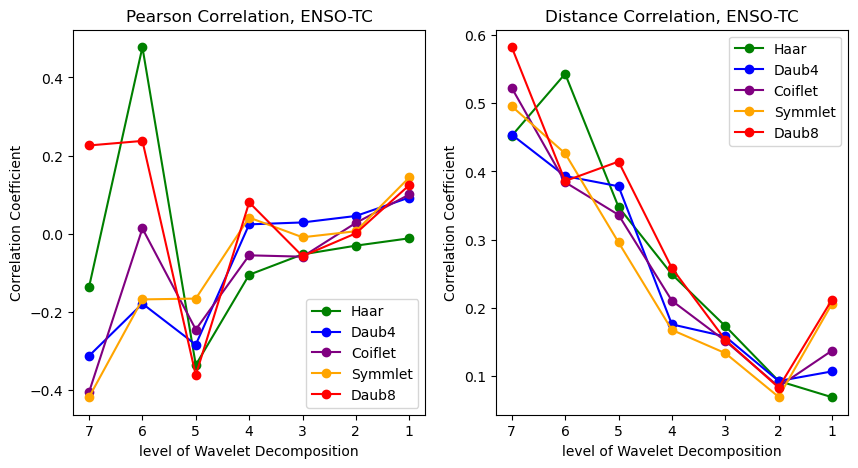

In [31]:
# different Wavelets
fig, ax = plt.subplots(1,2)
fig.set_size_inches(10, 5)

# Haar
ax[0].plot(range(1,8), haardf['nno_tcr'], '-o', color='g', label='Haar')
ax[1].plot(range(1,8), haardistdf['nno_tcr'], '-o', color='g', label='Haar')

# Daub4
ax[0].plot(range(1,8), d4df['nno_tcr'], '-o', color='b', label='Daub4')
ax[1].plot(range(1,8), d4distdf['nno_tcr'], '-o', color='b', label='Daub4')

# Coiflet 6
ax[0].plot(range(1,8), coifdf['nno_tcr'], '-o', color='purple', label='Coiflet')
ax[1].plot(range(1,8), coifdistdf['nno_tcr'], '-o', color='purple', label='Coiflet')

# Symmlet
ax[0].plot(range(1,8), symmdf['nno_tcr'], '-o', color='orange', label='Symmlet')
ax[1].plot(range(1,8), symdistdf['nno_tcr'], '-o', color='orange', label='Symmlet')

# original (Daub8)
ax[0].plot(range(1,8), corrsdf['nno_tcr'], '-o', color='r', label='Daub8')
ax[1].plot(range(1,8), distcorrsdf['nno_tcr'], '-o', color='r', label='Daub8')


ax[0].set_xticks(range(1,8), [7,6,5,4,3,2,1])
ax[0].set_xlabel('level of Wavelet Decomposition')
ax[0].set_ylabel('Correlation Coefficient')
ax[0].set_title('Pearson Correlation, ENSO-TC')
ax[0].legend(loc='lower right')

ax[1].set_xticks(range(1,8), [7,6,5,4,3,2,1])
ax[1].set_xlabel('level of Wavelet Decomposition')
ax[1].set_ylabel('Correlation Coefficient')
ax[1].set_title('Distance Correlation, ENSO-TC')
ax[1].legend(loc='upper right')

plt.legend()
plt.show()

# fig.savefig(f'GeoVisuals/comp_WavBases.png')

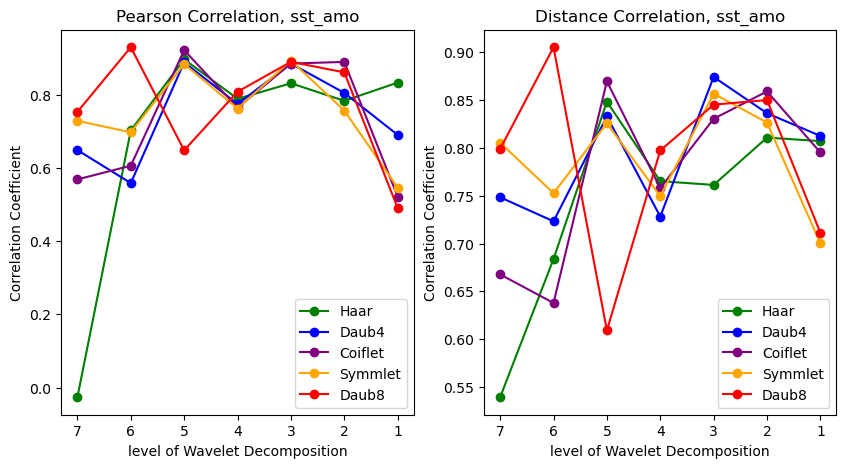

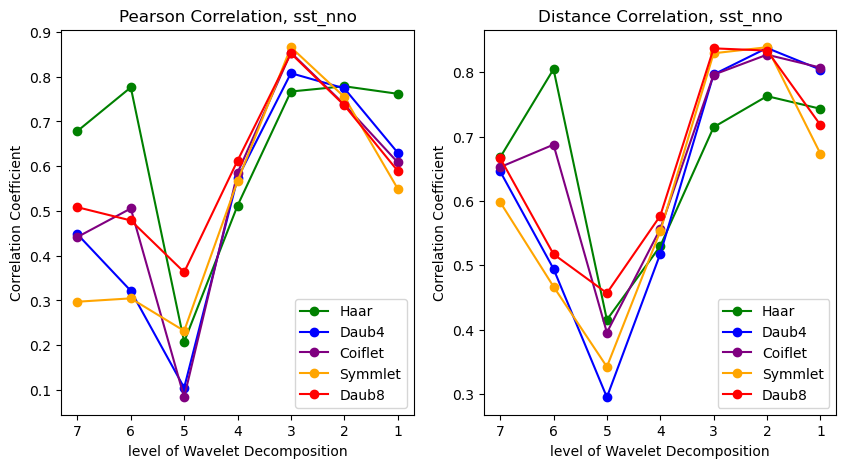

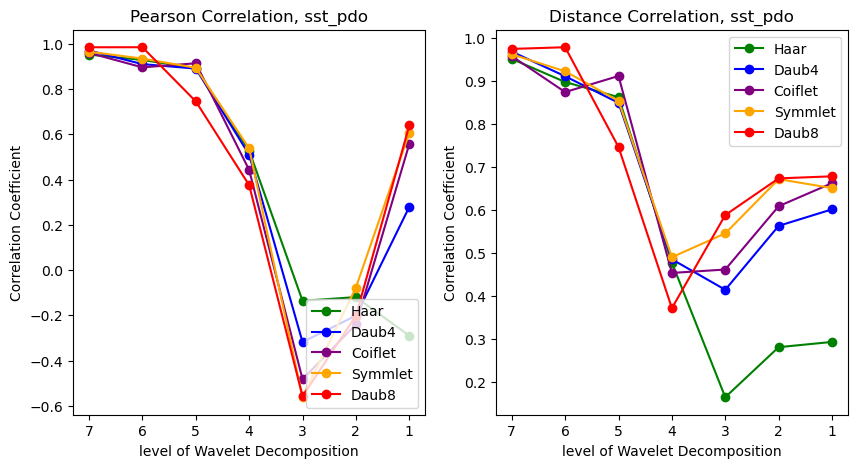

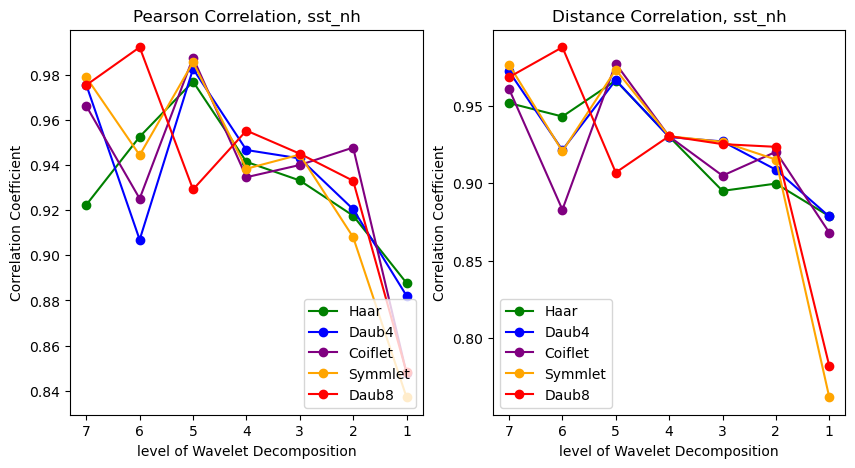

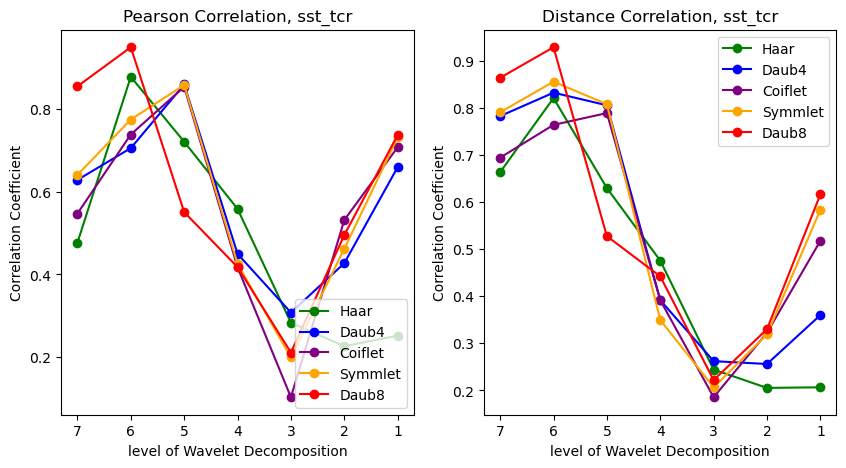

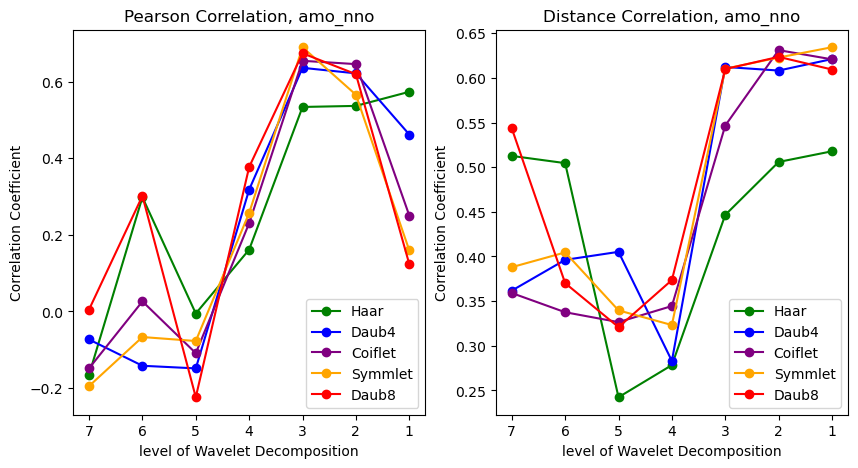

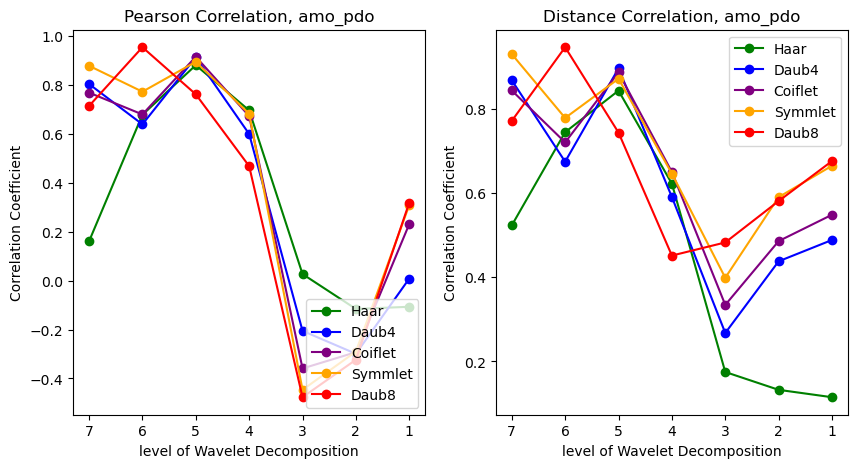

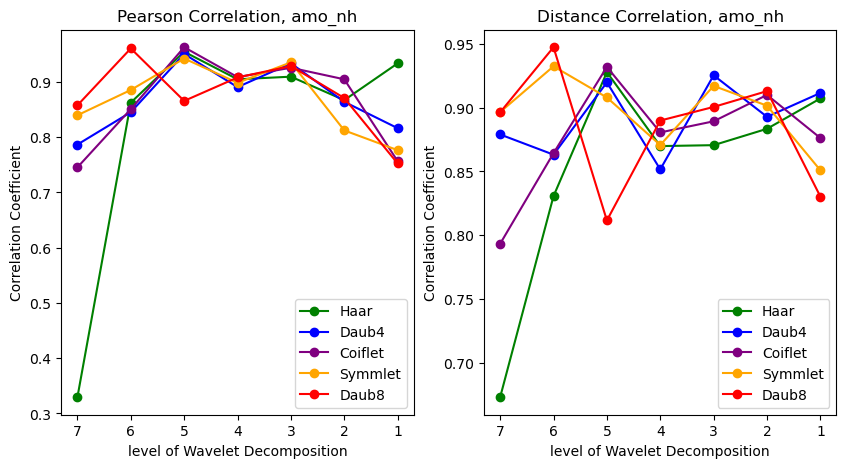

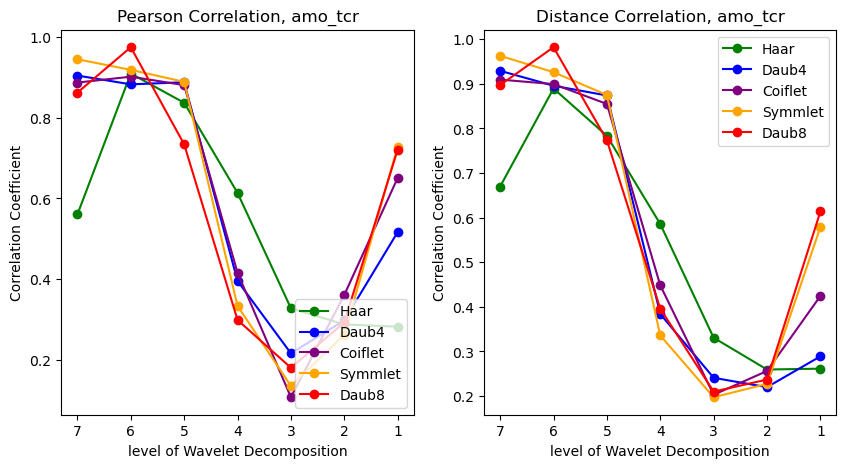

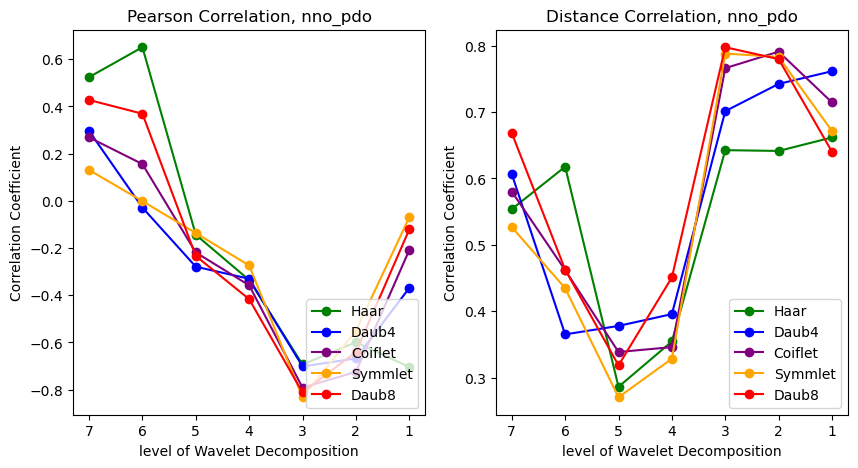

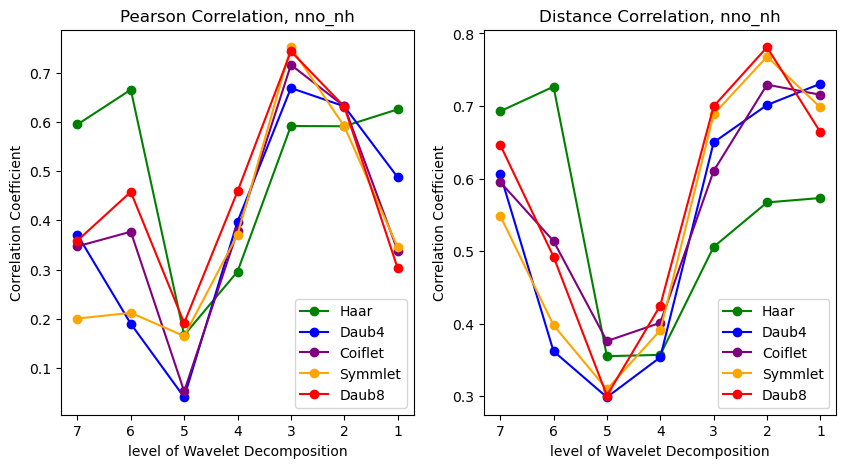

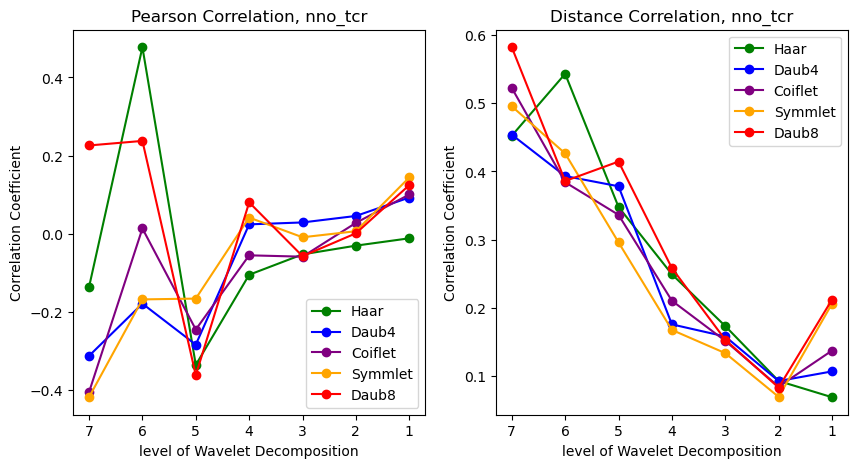

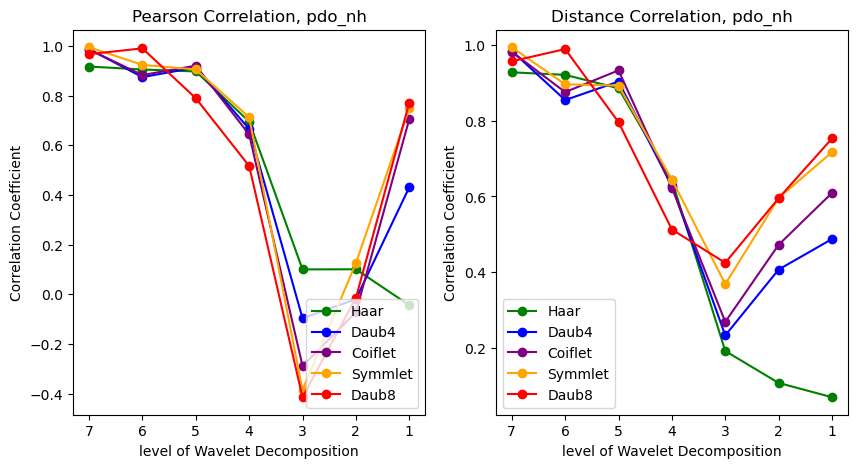

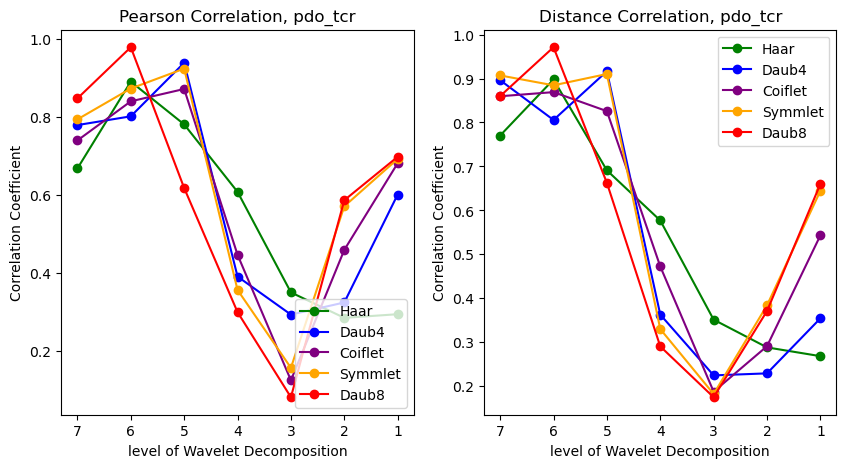

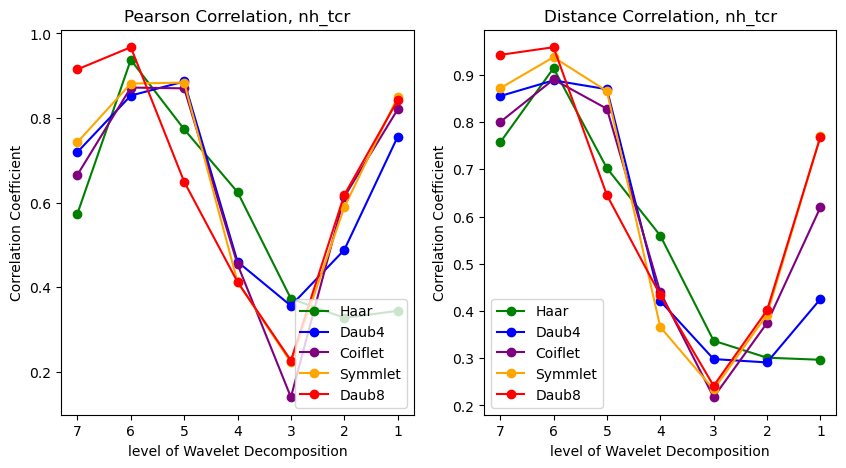

In [36]:
# compare some other variable pairs
varlist1 = list(corrsdf.columns)

for i in range(len(varlist1)):
    # different Wavelets
    fig, ax = plt.subplots(1,2)
    fig.set_size_inches(10, 5)

    # Haar
    ax[0].plot(range(1,8), haardf[varlist1[i]], '-o', color='g', label='Haar')
    ax[1].plot(range(1,8), haardistdf[varlist1[i]], '-o', color='g', label='Haar')

    # Daub4
    ax[0].plot(range(1,8), d4df[varlist1[i]], '-o', color='b', label='Daub4')
    ax[1].plot(range(1,8), d4distdf[varlist1[i]], '-o', color='b', label='Daub4')

    # Coiflet 6
    ax[0].plot(range(1,8), coifdf[varlist1[i]], '-o', color='purple', label='Coiflet')
    ax[1].plot(range(1,8), coifdistdf[varlist1[i]], '-o', color='purple', label='Coiflet')

    # Symmlet
    ax[0].plot(range(1,8), symmdf[varlist1[i]], '-o', color='orange', label='Symmlet')
    ax[1].plot(range(1,8), symdistdf[varlist1[i]], '-o', color='orange', label='Symmlet')

    # original (Daub8)
    ax[0].plot(range(1,8), corrsdf[varlist1[i]], '-o', color='r', label='Daub8')
    ax[1].plot(range(1,8), distcorrsdf[varlist1[i]], '-o', color='r', label='Daub8')


    ax[0].set_xticks(range(1,8), [7,6,5,4,3,2,1])
    ax[0].set_xlabel('level of Wavelet Decomposition')
    ax[0].set_ylabel('Correlation Coefficient')
    ax[0].set_title(f'Pearson Correlation, {varlist1[i]}')
    ax[0].legend(loc='lower right')

    ax[1].set_xticks(range(1,8), [7,6,5,4,3,2,1])
    ax[1].set_xlabel('level of Wavelet Decomposition')
    ax[1].set_ylabel('Correlation Coefficient')
    ax[1].set_title(f'Distance Correlation, {varlist1[i]}')
    ax[1].legend(loc='upper right')

    plt.legend()
    plt.show()